# MCP-Chain Agent - v7




## Session Note

Some outputs below may have been produced in earlier Colab sessions and not rerun in the current one. These headers are only structural guides.


## Environment and Dependencies

Install packages, mount Drive, set global paths, and prepare the notebook runtime.


In [26]:
!pip uninstall -y bitsandbytes
!pip install -U bitsandbytes>=0.46.1 accelerate transformers
!pip install faiss-cpu rank_bm25 sentence-transformers tqdm

Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2


In [57]:
import json, re, time, pickle, hashlib, random, os, datetime
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import faiss
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Ensure Google Drive is mounted
try:
    from google.colab import drive
    if not Path("/content/drive").exists():
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        # If /content/drive exists but isn't properly mounted, unmount and try again
        # This can happen if a previous session left a stale mount point
        try:
            # Attempt to access a known file in MyDrive to check mount status
            test_path = Path("/content/drive/MyDrive")
            if not test_path.exists() or not os.listdir(test_path):
                print("Detected potentially stale mount, unmounting and remounting...")
                drive.flush_and_unmount()
                drive.mount('/content/drive')
            else:
                print("Google Drive appears to be already mounted and accessible.")
        except Exception as e:
            print(f"Error checking or remounting drive: {e}. Attempting direct mount.")
            drive.mount('/content/drive') # Try to mount anyway

    # Verify mount
    DRIVE_DIR = Path("/content/drive/MyDrive/MCP_Research")
    if not DRIVE_DIR.is_dir():
        raise FileNotFoundError(
            f"Google Drive not mounted correctly or '{DRIVE_DIR}' not found. "
            "Please ensure 'MCP_Research' folder exists in your Google Drive 'MyDrive' root."
        )
    print(f"✅ Google Drive successfully mounted and '{DRIVE_DIR}' found."
)

except Exception as e:
    print(f"❌ Failed to mount Google Drive: {e}")
    print("Please ensure you are authenticated and 'MCP_Research' folder exists in your Google Drive 'MyDrive' root.")

# Rest of the original code
INDEX_DIR   = DRIVE_DIR / "indices"
RESULTS_DIR = DRIVE_DIR / "agent_results_v7"
CKPT_DIR    = RESULTS_DIR / "checkpoints"
DEMO_DIR    = RESULTS_DIR / "demo_runs"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
DEMO_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR.mkdir(parents=True, exist_ok=True)

EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
# MODEL_ID         = "mistralai/Mistral-7B-Instruct-v0.3"
# MODEL_KEY        = "mistral-7b"
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
MODEL_KEY = "qwen-2.5-7b"

DEFAULT_TOP_K      = 5
MAX_NEW_TOKENS     = 256
TEMPERATURE        = 0
MAX_PLAN_STEPS     = 8
MAX_STEP_RETRIES   = 3
MAX_PLAN_REVISIONS = 2
MAX_CHAIN_REPAIRS  = 1

REGISTRY_FILENAME  = "sealtools_mcp_registry.json"
GT_FILENAME        = "gt_sealtools_multi.jsonl"

# Retrieval recall k-values — used in scoring
RECALL_K_VALUES = [1, 3, 5, 10]

print("✅ Setup complete")
print("DRIVE_DIR :", DRIVE_DIR)
print("INDEX_DIR :", INDEX_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

Google Drive appears to be already mounted and accessible.
✅ Google Drive successfully mounted and '/content/drive/MyDrive/MCP_Research' found.
✅ Setup complete
DRIVE_DIR : /content/drive/MyDrive/MCP_Research
INDEX_DIR : /content/drive/MyDrive/MCP_Research/indices
RESULTS_DIR: /content/drive/MyDrive/MCP_Research/agent_results_v7


In [28]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [58]:
import zipfile
import os

zip_path = "/content/MCP_Research-20260408T104929Z-3-001.zip"
registry_filename = "sealtools_mcp_registry.json"

# Ensure DRIVE_DIR is defined and exists
if 'DRIVE_DIR' not in locals() or not DRIVE_DIR.exists():
    print("DRIVE_DIR not properly set or accessible. Please ensure Google Drive is mounted and the MCP_Research directory exists.")
else:
    print(f"Attempting to extract '{registry_filename}' from {zip_path} to {DRIVE_DIR}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            found_in_zip = False
            for file_info in zip_ref.infolist():
                # Check if the file name (or path within zip) matches the registry filename
                if registry_filename in file_info.filename:
                    # Construct the target path within DRIVE_DIR, ensuring no extra subdirs are created
                    target_file_path = DRIVE_DIR / registry_filename

                    # Extract the file directly to DRIVE_DIR, potentially overwriting existing
                    with zip_ref.open(file_info) as source, open(target_file_path, "wb") as target:
                        target.write(source.read())

                    print(f"  ✅ Extracted '{file_info.filename}' to '{target_file_path}'")
                    found_in_zip = True
                    break # Found and extracted, can stop

            if not found_in_zip:
                print(f"  ⚠️ Warning: '{registry_filename}' not found within the zip file. Listing top-level contents of zip for inspection:")
                for file_info in zip_ref.infolist():
                    if '/' not in file_info.filename and '\\' not in file_info.filename:
                        print(f"    - {file_info.filename}")
                print("  Please ensure the correct zip file is selected and contains 'sealtools_mcp_registry.json'.")

    except Exception as e:
        print(f"  ❌ Error during extraction: {e}")

# Verify if the registry file now exists
if (DRIVE_DIR / registry_filename).exists():
    print(f"✅ Verified: '{DRIVE_DIR / registry_filename}' now exists. You can now re-run cell jifEk_rlE0h2.")
else:
    print(f"❌ Error: '{DRIVE_DIR / registry_filename}' still not found after extraction attempt. Please check the zip file contents and try again.")

Attempting to extract 'sealtools_mcp_registry.json' from /content/MCP_Research-20260408T104929Z-3-001.zip to /content/drive/MyDrive/MCP_Research...
  ✅ Extracted 'MCP_Research/sealtools_mcp_registry.json' to '/content/drive/MyDrive/MCP_Research/sealtools_mcp_registry.json'
✅ Verified: '/content/drive/MyDrive/MCP_Research/sealtools_mcp_registry.json' now exists. You can now re-run cell jifEk_rlE0h2.


## Retrieval Stack and Registry Loading

Build lexical and dense retrieval views over the tool registry and initialize retrievers.


In [37]:
def build_bm25_text(tool: dict) -> str:
    """Keyword-heavy representation for lexical retrieval."""
    input_schema = tool.get("inputSchema", {}) or {}
    props    = input_schema.get("properties", {}) or {}
    required = input_schema.get("required", []) or []
    name     = tool.get("name", "")
    desc     = tool.get("description", "")
    domain   = tool.get("domain", "general")
    return " ".join([
        name, name.replace("_", " "), desc, domain,
        " ".join(props.keys()), " ".join(required), desc,
    ]).strip()


def build_dense_text(tool: dict) -> str:
    """Semantically rich representation for embedding retrieval."""
    input_schema = tool.get("inputSchema", {}) or {}
    props    = input_schema.get("properties", {}) or {}
    required = input_schema.get("required", []) or []
    param_lines = [f"- {k} ({v.get('type','any')}): {v.get('description','')}"
                   for k, v in props.items()]
    param_block  = "\n".join(param_lines) if param_lines else "- none"
    required_text = ", ".join(required) if required else "none"
    return (
        f"Tool name: {tool.get('name', '')}\n"
        f"Purpose: {tool.get('description', '')}\n"
        f"Domain: {tool.get('domain', 'general')}\n"
        f"Required parameters: {required_text}\n"
        f"Parameter descriptions:\n{param_block}\n"
        f"This tool is useful when the user explicitly asks for this action or information."
    )


def load_registry(filename: str) -> list:
    with open(DRIVE_DIR / filename) as f:
        data = json.load(f)
    tools = data["tools"]
    print(f"✅ Loaded {filename}: {len(tools)} tools")
    with_domain = sum(1 for t in tools if t.get("domain") and t["domain"] != "general")
    print(f"   Tools with real domain: {with_domain}/{len(tools)}")
    return tools


def _builder_signature(builder_name: str, tools: list) -> str:
    sig_src = f"{builder_name}|{len(tools)}"
    return hashlib.md5(sig_src.encode()).hexdigest()[:10]


class DenseRetriever:
    def __init__(self, tools: list, text_builder=build_dense_text,
                 model_name: str = EMBED_MODEL_NAME):
        self.tools        = tools
        self.text_builder = text_builder
        self.model_name   = model_name
        self.model        = None
        self.index        = None
        self.texts        = [self.text_builder(t) for t in tools]
        self.index_name   = None

    def _cache_paths(self, name: str):
        sig = _builder_signature(
            getattr(self.text_builder, "__name__", "builder"), self.tools)
        index_name = f"{name}_{sig}_{self.model_name.replace('/', '_')}"
        return index_name, INDEX_DIR / f"{index_name}.faiss", INDEX_DIR / f"{index_name}_meta.pkl"

    def load_or_build(self, name: str):
        self.model = SentenceTransformer(self.model_name)
        self.index_name, index_path, meta_path = self._cache_paths(name)

        if index_path.exists() and meta_path.exists():
            self.index = faiss.read_index(str(index_path))
            with open(meta_path, "rb") as f:
                meta = pickle.load(f)
            self.texts = meta["texts"]
            print(f"✅ Dense cache loaded: {self.index_name} ({self.index.ntotal} vectors)")
            return

        # Try loading embeddings saved by RAG pipeline notebook
        emb_path = DRIVE_DIR / f"{name}_embeddings.npy"
        if emb_path.exists():
            print(f"Loading pre-computed embeddings from RAG pipeline: {emb_path}")
            embeddings = np.load(str(emb_path)).astype("float32")
        else:
            print(f"Building dense index: {self.index_name} (no cached embeddings found)")
            embeddings = self.model.encode(
                self.texts, normalize_embeddings=True,
                convert_to_numpy=True, show_progress_bar=True,
            ).astype("float32")

        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        self.index.add(embeddings)
        faiss.write_index(self.index, str(index_path))
        with open(meta_path, "wb") as f:
            pickle.dump({"texts": self.texts, "model_name": self.model_name,
                         "builder_name": getattr(self.text_builder, "__name__", "builder")}, f)
        print(f"✅ Dense index built + saved: {self.index_name}")

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        q_emb = self.model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")
        scores, indices = self.index.search(q_emb, k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx < 0:
                continue
            tool = dict(self.tools[idx])
            tool["_score"]     = float(score)
            tool["_retriever"] = "dense"
            results.append(tool)
        return results


class BM25Retriever:
    def __init__(self, tools: list, text_builder=build_bm25_text):
        self.tools        = tools
        self.text_builder = text_builder
        self.corpus       = [self.text_builder(t) for t in tools]
        self.tokens       = [self._tokenize(x) for x in self.corpus]
        self.bm25         = BM25Okapi(self.tokens)

    @staticmethod
    def _tokenize(text: str) -> list:
        return re.sub(r"[^a-zA-Z0-9]", " ", text.lower()).split()

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        scores  = self.bm25.get_scores(self._tokenize(query))
        top_idx = np.argsort(scores)[::-1][:k]
        results = []
        for idx in top_idx:
            tool = dict(self.tools[idx])
            tool["_score"]     = float(scores[idx])
            tool["_retriever"] = "bm25"
            results.append(tool)
        return results


sealtools = load_registry(REGISTRY_FILENAME)

dense_retriever = DenseRetriever(sealtools, text_builder=build_dense_text)
dense_retriever.load_or_build("sealtools_dense_text")

bm25_retriever = BM25Retriever(sealtools, text_builder=build_bm25_text)

print("✅ Retrievers ready")
print("Dense text sample:\n", build_dense_text(sealtools[0])[:400])
print("\nBM25 text sample:\n", build_bm25_text(sealtools[0])[:200])

✅ Loaded sealtools_mcp_registry.json: 4076 tools
   Tools with real domain: 4076/4076


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building dense index: sealtools_dense_text_dc780e49c2_all-MiniLM-L6-v2 (no cached embeddings found)


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

✅ Dense index built + saved: sealtools_dense_text_dc780e49c2_all-MiniLM-L6-v2
✅ Retrievers ready
Dense text sample:
 Tool name: analyzeEvidence
Purpose: Analyze the chemical evidence collected from a crime scene
Domain: Chemical Engineering/Forensic engineering
Required parameters: evidence_type, method, sample
Parameter descriptions:
- evidence_type (string): The type of evidence to be analyzed (e.g., DNA, fingerprints, blood, fibers)
- method (string): The method or technique to be used for analysis (e.g., spe

BM25 text sample:
 analyzeEvidence analyzeEvidence Analyze the chemical evidence collected from a crime scene Chemical Engineering/Forensic engineering evidence_type method sample evidence_type method sample Analyze the


In [30]:
import os

# Assuming DRIVE_DIR is defined as Path("/content/drive/MyDrive/MCP_Research")
# If not, please define it first, or provide the correct path.

if 'DRIVE_DIR' in locals() and os.path.exists(DRIVE_DIR):
    print(f"Listing contents of {DRIVE_DIR}:")
    for item in os.listdir(DRIVE_DIR):
        print(f"- {item}")
else:
    print(f"DRIVE_DIR is not defined or does not exist: {DRIVE_DIR}")
    print("Please ensure Google Drive is mounted and the MCP_Research directory path is correct.")

Listing contents of /content/drive/MyDrive/MCP_Research:
- indices
- agent_results_v7


## Base LLM Loading

Load the generator model used by the metacognitive agent.


In [ ]:
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
model.eval()

print(f"✅ Model loaded in {time.time() - t0:.1f}s")
print(f"VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Model loaded in 122.7s
VRAM allocated: 8.71 GB


## Prompt Templates

Core prompts for planning, tool selection, review, and final answer generation.


In [ ]:
def llm_generate(prompt: str,
                 max_new_tokens: int = MAX_NEW_TOKENS,
                 temperature: float = TEMPERATURE) -> str:
    device = next(model.parameters()).device

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(device)

    n_input = inputs["input_ids"].shape[1]

    gen_kwargs = dict(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=(temperature > 0),
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.1,
    )

    if temperature > 0:
        gen_kwargs["temperature"] = temperature

    with torch.no_grad():
        output_ids = model.generate(**gen_kwargs)

    generated = output_ids[0][n_input:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


PLAN_CONFIDENCE_THRESHOLD = 0.70
# TOOL_CONFIDENCE_THRESHOLD = 0.72
TOOL_CONFIDENCE_THRESHOLD = 0.40


PLAN_PROMPT = """
You are planning for a tool-using agent.

Your job is to decompose the user's request into the MINIMUM number of steps needed for tool execution.

Rules:
- Produce only the essential steps needed to complete the request.
- Each step should correspond to one concrete tool action whenever possible.
- Do NOT include vague human workflow steps such as search online, browse websites, find a provider, contact customer service, or log into a portal unless absolutely necessary because no direct tool can perform the action.
- If the user request already contains enough information for a tool call, write a direct step for that action.
- Avoid duplicate or overlapping steps.
- Keep the plan concise and tool-oriented.
- Output ONLY the numbered plan steps and the final PLAN_CONFIDENCE line.
- Do NOT repeat or restate any rules or instructions from this prompt.

Format:
1. <step>
2. <step>
...
PLAN_CONFIDENCE: <score>

User query:
{query}
"""


PLAN_REVIEW_PROMPT = """
You are reviewing a proposed tool-execution plan for the user query because the planner confidence is low.

Your job is to decide whether the plan is good as-is or whether it should be revised.

Check for:
1. unnecessary decomposition
2. duplicate coverage of the same user subtask
3. vague human-style actions when a direct tool step would be better
4. missing subtasks from the original user request
5. incorrect ordering of subtasks

A good plan should:
- use the minimum number of steps needed
- map closely to direct tool actions
- avoid redundancy
- cover the full user request

Respond in EXACT format:

VERDICT: ACCEPT

or

VERDICT: REPLAN
ISSUE: <short explanation>
REVISED_PLAN:
1. <step>
2. <step>

User query:
{query}

Proposed plan:
{plan_text}

Planner confidence:
{plan_confidence}
"""


TOOL_SELECTION_PROMPT = """
You are choosing the best tool for a single step in a plan.

Pick the ONE best tool for the current step.

Rules:
1. Prefer the most direct and relevant tool for the step.
2. Avoid selecting tools that only partially match if a stronger match exists.
3. If the step appears redundant with a previous completed step, mention that in the redundancy field.
4. Extract parameters only from the user query and the current step context.
5. Do not invent parameters that are not grounded in the input.

Respond in EXACT format:
SELECTED_TOOL: <tool name from the list, or NONE>
CONFIDENCE: <float 0.0-1.0>
RATIONALE: <one sentence>
IS_REDUNDANT: <true or false>
PARAMETERS_JSON:
{{"key": "value"}}

User query:
{query}

Full plan:
{plan_text}

Previous completed steps:
{completed_steps_text}

Current step:
{step_text}

Candidate tools:
{candidate_tools_text}
"""


CHAIN_REVIEW_PROMPT = """You are checking whether the selected tools and generated parameters are correct.

Your scope is limited to:
- tool relevance for each step
- parameter grounding in the original query
- whether any low-confidence step should be requeried
- whether any step is unnecessary and should be removed
- whether a missing step is needed and should be added

Only propose REMOVE or ADD if it is clearly necessary based on the original query and the existing chain.
Prefer REQUERY over structural changes when possible.

Original query:
{query}

Plan:
{plan_text}

Executed steps:
{chain_text}

Low-confidence steps:
{low_conf_steps_text}

For each low-confidence step, check:
- Is the selected tool relevant to the step?
- Are the parameters grounded in the query and step text?
- Is the step unnecessary and should be removed?
- Is a missing step needed to fully satisfy the query?

Respond in EXACT JSON:

{{
  "chain_valid": true,
  "issue": "",
  "fixes": []
}}

or

{{
  "chain_valid": false,
  "issue": "<one sentence explaining what is wrong>",
  "fixes": [
    {{
      "step_index": 2,
      "action": "REQUERY",
      "fixed_step_query": "<better step text for retrieval/tool selection>"
    }},
    {{
      "step_index": 3,
      "action": "REMOVE",
      "fixed_step_query": ""
    }},
    {{
      "step_index": 4,
      "action": "ADD",
      "fixed_step_query": "<missing step text to add>"
    }}
  ]
}}
"""


FINAL_ANSWER_PROMPT = """Answer the user based on the executed tool chain.

Original query:
{query}

Executed steps:
{chain_text}

Give a concise final answer in 2-4 sentences."""


BAD_PLAN_PREFIXES = (
    "produce only",
    "each step should",
    "do not include",
    "output only",
    "do not repeat",
    "format:",
    "rules:",
    "also provide",
    "keep the plan concise",
    "avoid duplicate",
    "if the user request already contains",
)


def clean_plan_steps(steps: list, max_items: int = MAX_PLAN_STEPS) -> list:
    cleaned = []
    seen = set()

    for step in steps:
        if not isinstance(step, str):
            continue

        s = step.strip()
        if not s:
            continue

        s_lower = s.lower()

        if s.startswith("<") and s.endswith(">"):
            continue
        if s_lower in ("...", "return only", "numbered steps"):
            continue
        if s_lower.startswith(BAD_PLAN_PREFIXES):
            continue

        if s_lower not in seen:
            cleaned.append(s)
            seen.add(s_lower)

        if len(cleaned) >= max_items:
            break

    return cleaned


def parse_numbered_list(raw: str, max_items: int = MAX_PLAN_STEPS) -> list:
    items = []
    for line in raw.splitlines():
        m = re.match(r"^\s*\d+[\.)]\s*(.+?)\s*$", line)
        if m:
            items.append(m.group(1).strip())
    return clean_plan_steps(items, max_items=max_items)


def parse_confidence(raw: str, prefix: str, default: float = 0.5) -> float:
    for line in raw.splitlines():
        if line.strip().startswith(prefix):
            try:
                return max(0.0, min(1.0, float(line.split(":", 1)[1].strip())))
            except Exception:
                return default
    return default


def parse_plan_output(raw: str) -> tuple:
    confidence = parse_confidence(raw, "PLAN_CONFIDENCE:", default=0.5)
    steps = parse_numbered_list(raw)
    return confidence, steps


def parse_plan_review(raw: str) -> tuple:
    verdict = "ACCEPT"
    issue = ""
    revised_plan = []
    for line in raw.splitlines():
        if line.startswith("VERDICT:") and "REPLAN" in line.upper():
            verdict = "REPLAN"
        elif line.startswith("ISSUE:"):
            issue = line.split(":", 1)[1].strip()
    if "REVISED_PLAN:" in raw:
        after = raw.split("REVISED_PLAN:", 1)[1].strip()
        if not after.upper().startswith("NONE"):
            revised_plan = parse_numbered_list(after)
    return verdict, issue, revised_plan


def parse_selected_tool(raw: str, candidates: list) -> tuple:
    tool_name = "NONE"
    tool_confidence = parse_confidence(raw, "CONFIDENCE:", default=0.5)
    rationale = ""
    is_redundant = False
    for line in raw.splitlines():
        if line.startswith("SELECTED_TOOL:"):
            candidate = line.split(":", 1)[1].strip()
            if candidate in candidates:
                tool_name = candidate
            else:
                for c in candidates:
                    if c.lower() == candidate.lower():
                        tool_name = c
                        break
        elif line.startswith("RATIONALE:"):
            rationale = line.split(":", 1)[1].strip()
        elif line.startswith("IS_REDUNDANT:"):
            val = line.split(":", 1)[1].strip().lower()
            is_redundant = (val == "true")
    params = {}
    m = re.search(r"\{.*\}", raw, re.DOTALL)
    if m:
        try:
            params = json.loads(m.group(0))
        except Exception:
            params = {}
    return tool_name, tool_confidence, rationale, params, is_redundant


def parse_chain_review(raw: str) -> tuple:
    raw = raw.strip()
    try:
        obj = json.loads(raw)
    except Exception:
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        if not m:
            return True, [], ""
        try:
            obj = json.loads(m.group(0))
        except Exception:
            return True, [], ""
    chain_valid = bool(obj.get("chain_valid", True))
    issue = obj.get("issue", "") or ""
    fixes = obj.get("fixes", []) or []
    cleaned_fixes = []
    for fix in fixes:
        if not isinstance(fix, dict):
            continue
        step_index = fix.get("step_index", None)
        action = str(fix.get("action", "")).upper().strip()
        fixed_step_query = str(fix.get("fixed_step_query", "")).strip()
        if action not in {"REQUERY", "REMOVE", "ADD"}:
            continue
        try:
            step_index = int(step_index) if step_index is not None else None
        except Exception:
            step_index = None
        cleaned_fixes.append({"step_index": step_index, "action": action,
                               "fixed_step_query": fixed_step_query})
    return chain_valid, cleaned_fixes, issue


def normalize_value(v):
    if v is None:
        return None
    if isinstance(v, (int, float, bool)):
        return v
    return str(v).strip().lower()


def simulate_tool_call(tool_name: str, params: dict) -> dict:
    return {
        "status": "success",
        "tool": tool_name,
        "parameters": params,
        "result": f"[Simulated] {tool_name}({json.dumps(params, ensure_ascii=False)})"
    }


print("✅ Prompts + parsers ready")

✅ Prompts + parsers ready


## Traces, Scoring, and Result Utilities

Define the dataclasses and helper logic used to store agent trajectories and compute metrics.


In [ ]:
@dataclass
class StepTrace:
    step_idx: int
    original_step: str
    final_step: str
    selected_tool: str
    confidence: float
    low_confidence: bool
    rationale: str
    params: dict
    tool_output: dict
    candidates: list
    retrieved_tools: list
    attempts: int
    decision: str
    issue: str
    requery_count: int = 0
    replan_count: int = 0
    latency_ms: float = 0.0


@dataclass
class AgentResult:
    query: str
    model_key: str
    retriever_type: str
    config_name: str
    plan: list
    final_plan: list
    plan_confidence: float
    plan_review_triggered: bool
    plan_issue: str
    low_confidence_steps: list
    steps: list
    predicted_tool_chain: list
    predicted_tool_calls: list
    chain_valid: bool
    chain_action: str
    chain_issue: str
    repaired: bool
    total_latency_ms: float
    task_complete: bool
    timestamp: str


print("✅ Dataclasses ready")

✅ Dataclasses ready


## Agent Classes

Transition point from trace/result utilities into the runnable agent implementations and baselines.


## LLM Agent Implementation

Primary metacognitive agent classes, tracing structures, and evaluation-facing runtime logic.


In [ ]:
class MCPChainAgent:
    """Confidence-gated metacognitive agent with plan review and targeted chain review."""
    def __init__(self, retriever, retriever_type: str = "dense",
                 config_name: str = "full", top_k: int = DEFAULT_TOP_K,
                 requery_top_k: int = None, max_chain_repairs: int = MAX_CHAIN_REPAIRS,
                 use_reflection: bool = True, verbose: bool = True,
                 plan_conf_threshold: float = PLAN_CONFIDENCE_THRESHOLD,
                 tool_conf_threshold: float = TOOL_CONFIDENCE_THRESHOLD):
        self.retriever           = retriever
        self.retriever_type      = retriever_type
        self.config_name         = config_name
        self.top_k               = top_k
        self.requery_top_k       = requery_top_k if requery_top_k is not None else top_k + 3
        self.max_chain_repairs   = max_chain_repairs
        self.use_reflection      = use_reflection
        self.verbose             = verbose
        self.plan_conf_threshold = plan_conf_threshold
        self.tool_conf_threshold = tool_conf_threshold
        self._current_plan       = []
        self._current_traces     = []

    def _log(self, msg):
        if self.verbose: print(msg)

    def _retrieve(self, query_text: str, top_k: int = None) -> list:
        return self.retriever.search(query_text, k=top_k if top_k is not None else self.top_k)

    def _format_tool_list(self, retrieved: list) -> str:
        return "\n".join(
            f"{i}. {t.get('name','')} | {t.get('description','')[:140]} | score={t.get('_score',0):.4f}"
            for i, t in enumerate(retrieved, 1)
        )

    def _normalize_param_keys(self, params: dict) -> dict:
        if not isinstance(params, dict):
            return {}
        key_aliases = {
            "businessType": "business_type", "employeeCount": "employee_count",
            "injuryType": "injury_type", "businessLocationState": "state",
            "numEmployees": "employee_count", "coverageType": "coverage_type",
        }
        return {key_aliases.get(k, k): v for k, v in params.items()}

    def _generate_plan(self, query: str) -> tuple:
        raw_plan = llm_generate(PLAN_PROMPT.format(query=query), max_new_tokens=220)
        plan_confidence, plan = parse_plan_output(raw_plan)
        return plan or [query], plan_confidence, raw_plan

    def _review_plan_if_needed(self, query: str, plan: list, plan_confidence: float) -> tuple:
        if (not self.use_reflection) or plan_confidence >= self.plan_conf_threshold:
            return plan, False, ""
        plan_text = "\n".join(f"{i+1}. {s}" for i, s in enumerate(plan))
        review_raw = llm_generate(
            PLAN_REVIEW_PROMPT.format(query=query, plan_confidence=f"{plan_confidence:.2f}",
                                      plan_text=plan_text), max_new_tokens=256)
        verdict, issue, revised_plan = parse_plan_review(review_raw)
        if verdict == "REPLAN" and revised_plan:
            return revised_plan, True, issue
        return plan, True, issue

    def _run_step(self, query: str, step: str, step_idx: int, force_top_k: int = None):
        t0 = time.perf_counter()
        effective_top_k = force_top_k if force_top_k is not None else self.top_k
        retrieved = self._retrieve(step, top_k=effective_top_k)
        candidates = [r["name"] for r in retrieved]
        retrieved_names = candidates[:]
        completed_steps_text = "\n".join(
            f"{i+1}. {t.final_step} → {t.selected_tool}"
            for i, t in enumerate(self._current_traces)) or "None"
        plan_text = "\n".join(
            f"{i+1}. {s}" for i, s in enumerate(self._current_plan)) or f"1. {step}"
        choice_raw = llm_generate(
            TOOL_SELECTION_PROMPT.format(
                query=query, plan_text=plan_text,
                completed_steps_text=completed_steps_text,
                step_text=step, candidate_tools_text=self._format_tool_list(retrieved)),
            max_new_tokens=220)
        selected_tool, tool_confidence, rationale, params, _ = parse_selected_tool(choice_raw, candidates)
        params = self._normalize_param_keys(params)
        low_confidence = (selected_tool == "NONE" or tool_confidence < self.tool_conf_threshold)
        issue = ""
        if selected_tool == "NONE":
            issue = "No valid tool selected from retrieved candidates."
            tool_output = {"status": "failed", "tool": "NONE", "parameters": params,
                           "result": "[Simulated] NONE"}
        else:
            tool_output = simulate_tool_call(selected_tool, params)
        return StepTrace(
            step_idx=step_idx, original_step=step, final_step=step,
            selected_tool=selected_tool, confidence=tool_confidence,
            low_confidence=low_confidence, rationale=rationale, params=params,
            tool_output=tool_output, candidates=candidates, retrieved_tools=retrieved_names,
            attempts=1, decision="ACCEPT" if not low_confidence else "LOW_CONFIDENCE",
            issue=issue, requery_count=0, replan_count=0,
            latency_ms=(time.perf_counter() - t0) * 1000)

    def _execute_plan(self, query: str, plan: list) -> list:
        traces = []
        self._current_plan   = plan[:]
        self._current_traces = []
        for idx, step in enumerate(plan):
            self._log(f"\n[STEP {idx+1}/{len(plan)}] {step}")
            trace = self._run_step(query, step, idx)
            traces.append(trace)
            self._current_traces = traces[:]
            self._log(f"  → tool={trace.selected_tool} confidence={trace.confidence:.2f} "                      f"low_conf={trace.low_confidence}")
            if trace.issue:
                self._log(f"    issue: {trace.issue}")
        return traces

    def _low_confidence_summary(self, traces: list) -> tuple:
        rows, low_conf_steps = [], []
        for t in traces:
            if getattr(t, "low_confidence", False):
                rows.append(f"step {t.step_idx+1}: {t.final_step} | tool={t.selected_tool} | "                            f"confidence={t.confidence:.2f} | params={json.dumps(t.params)} | "                            f"issue={t.issue or 'NONE'}")
                low_conf_steps.append(t.step_idx)
        return ("\n".join(rows) if rows else "NONE"), low_conf_steps

    def _review_chain(self, query: str, plan: list, traces: list, low_conf_steps: list):
        if not low_conf_steps:
            return True, [], ""
        chain_text = "\n".join(
            f"{i+1}. step=[{t.final_step}] tool=[{t.selected_tool}] "            f"params={json.dumps(t.params)} confidence={t.confidence:.2f}"
            for i, t in enumerate(traces))
        plan_text = "\n".join(f"{i+1}. {s}" for i, s in enumerate(plan))
        raw = llm_generate(
            CHAIN_REVIEW_PROMPT.format(
                query=query, plan_text=plan_text, chain_text=chain_text,
                low_conf_steps_text=", ".join(str(i+1) for i in low_conf_steps)),
            max_new_tokens=220)
        return parse_chain_review(raw)

    def _rerun_single_step(self, query, plan, existing_traces, step_text, step_idx):
        self._current_plan   = plan[:]
        self._current_traces = existing_traces[:]
        return self._run_step(query=query, step=step_text, step_idx=step_idx,
                              force_top_k=self.requery_top_k)

    def _apply_chain_fixes(self, query, plan, traces, fixes):
        updated_plan   = plan[:]
        updated_traces = traces[:]
        offset = 0
        for fix in fixes:
            action           = fix.get("action", "").upper().strip()
            step_index       = fix.get("step_index", None)
            fixed_step_query = fix.get("fixed_step_query", "").strip()
            idx = len(updated_traces) if step_index is None else max(0, step_index - 1 + offset)
            if action == "REMOVE":
                if 0 <= idx < len(updated_traces):
                    updated_traces.pop(idx)
                    if 0 <= idx < len(updated_plan): updated_plan.pop(idx)
                    offset -= 1
            elif action == "REQUERY":
                if 0 <= idx < len(updated_traces):
                    new_step_text = fixed_step_query or updated_traces[idx].final_step
                    if 0 <= idx < len(updated_plan): updated_plan[idx] = new_step_text
                    updated_traces[idx] = self._rerun_single_step(
                        query, updated_plan, updated_traces[:idx], new_step_text, idx)
            elif action == "ADD":
                if not fixed_step_query: continue
                if idx > len(updated_plan): idx = len(updated_plan)
                updated_plan.insert(idx, fixed_step_query)
                new_trace = self._rerun_single_step(
                    query, updated_plan, updated_traces[:idx], fixed_step_query, idx)
                updated_traces.insert(idx, new_trace)
                offset += 1
        reindexed = [
            StepTrace(step_idx=new_idx, original_step=t.original_step, final_step=t.final_step,
                      selected_tool=t.selected_tool, confidence=t.confidence,
                      low_confidence=t.low_confidence, rationale=t.rationale,
                      params=t.params, tool_output=t.tool_output, candidates=t.candidates,
                      retrieved_tools=t.retrieved_tools, attempts=t.attempts,
                      decision=t.decision, issue=t.issue, requery_count=t.requery_count,
                      replan_count=t.replan_count, latency_ms=t.latency_ms)
            for new_idx, t in enumerate(updated_traces)
        ]
        return updated_plan, reindexed

    def run(self, query: str) -> AgentResult:
        t_start = time.perf_counter()
        self._log(f"\n{'='*80}\nQUERY: {query}\n{'='*80}")
        plan, plan_confidence, _ = self._generate_plan(query)
        final_plan, plan_review_triggered, plan_issue = self._review_plan_if_needed(
            query, plan, plan_confidence)
        traces = self._execute_plan(query, final_plan)
        low_conf_text, low_conf_steps = self._low_confidence_summary(traces)
        chain_valid, chain_action, chain_issue, repaired = True, "ACCEPT", "", False
        if self.use_reflection and low_conf_steps:
            for _ in range(self.max_chain_repairs):
                chain_valid, fixes, chain_issue = self._review_chain(
                    query=query, plan=final_plan, traces=traces, low_conf_steps=low_conf_steps)
                chain_action = "ACCEPT" if chain_valid else "REPAIR"
                if chain_valid or not fixes:
                    break
                repaired = True
                final_plan, traces = self._apply_chain_fixes(query, final_plan, traces, fixes)
                low_conf_text, low_conf_steps = self._low_confidence_summary(traces)
                if not low_conf_steps:
                    chain_valid, chain_action, chain_issue = True, "ACCEPT", ""
                    break
        predicted_tool_chain = [s.selected_tool for s in traces
                                if s.selected_tool and s.selected_tool != "NONE"]
        predicted_tool_calls = [{"tool": s.selected_tool,
                                  "parameters": self._normalize_param_keys(s.params)}
                                for s in traces if s.selected_tool and s.selected_tool != "NONE"]
        task_complete = (bool(predicted_tool_chain) and chain_valid and
                         all(s.selected_tool != "NONE" for s in traces))
        return AgentResult(
            query=query, model_key=MODEL_KEY, retriever_type=self.retriever_type,
            config_name=self.config_name, plan=plan, final_plan=final_plan,
            plan_confidence=plan_confidence, plan_review_triggered=plan_review_triggered,
            plan_issue=plan_issue, low_confidence_steps=low_conf_steps, steps=traces,
            predicted_tool_chain=predicted_tool_chain, predicted_tool_calls=predicted_tool_calls,
            chain_valid=chain_valid, chain_action=chain_action, chain_issue=chain_issue,
            repaired=repaired, total_latency_ms=(time.perf_counter() - t_start) * 1000,
            task_complete=task_complete,
            timestamp=datetime.datetime.utcnow().isoformat() + "Z")


print("✅ MCPChainAgent ready")

✅ MCPChainAgent ready


## Static Retrieval Baseline

Optional non-LLM baseline kept for comparison with the main metacognitive agent.


In [ ]:
class StaticRAGAgent:
    """
    Top-k RAG agent — retrieves top-k tools and predicts them as the chain.
    No planning or LLM. Fair baseline for multi-step GT comparison.
    One StepTrace per retrieved tool so retrieval_recall@k scoring works correctly.
    """

    def __init__(self, retriever, retriever_type: str = "bm25",
                 config_name: str = "static", top_k: int = DEFAULT_TOP_K,
                 verbose: bool = False):
        self.retriever      = retriever
        self.retriever_type = retriever_type
        self.config_name    = config_name
        self.top_k          = top_k
        self.verbose        = verbose

    def run(self, query: str) -> AgentResult:
        t0        = time.perf_counter()
        retrieved = self.retriever.search(query, k=self.top_k)
        candidates = [r["name"] for r in retrieved]

        # Predict all top-k tools as the chain (not just top-1)
        predicted_tool_chain = candidates[:]
        predicted_tool_calls = [{"tool": t, "parameters": {}} for t in candidates]

        # One trace per tool so retrieval_recall scoring has retrieved_tools per step
        traces = []
        for i, tool_name in enumerate(predicted_tool_chain):
            traces.append(StepTrace(
                step_idx=i, original_step=query, final_step=query,
                selected_tool=tool_name, confidence=1.0, low_confidence=False,
                rationale=f"Top-{i+1} retrieval (no LLM)", params={},
                tool_output=simulate_tool_call(tool_name, {}),
                candidates=candidates, retrieved_tools=candidates,
                attempts=1, decision="ACCEPT", issue="",
                requery_count=0, replan_count=0,
                latency_ms=(time.perf_counter() - t0) * 1000))

        task_complete = bool(predicted_tool_chain)

        return AgentResult(
            query=query, model_key="static", retriever_type=self.retriever_type,
            config_name=self.config_name, plan=[query], final_plan=[query],
            plan_confidence=1.0, plan_review_triggered=False, plan_issue="",
            low_confidence_steps=[], steps=traces,
            predicted_tool_chain=predicted_tool_chain,
            predicted_tool_calls=predicted_tool_calls,
            chain_valid=True, chain_action="ACCEPT", chain_issue="",
            repaired=False,
            total_latency_ms=(time.perf_counter() - t0) * 1000,
            task_complete=task_complete,
            timestamp=datetime.datetime.utcnow().isoformat() + "Z")


def safe_slug(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-]+", "_", text.strip().lower())


def save_agent_result(result: AgentResult, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    stamp = str(int(time.time()))
    path  = out_dir / f"{safe_slug(result.config_name)}_{stamp}.json"
    payload = {
        "query": result.query, "model_key": result.model_key,
        "retriever_type": result.retriever_type, "config_name": result.config_name,
        "plan": result.plan, "final_plan": result.final_plan,
        "plan_confidence": result.plan_confidence,
        "plan_review_triggered": result.plan_review_triggered,
        "plan_issue": result.plan_issue,
        "low_confidence_steps": result.low_confidence_steps,
        "steps": [asdict(s) for s in result.steps],
        "predicted_tool_chain": result.predicted_tool_chain,
        "predicted_tool_calls": result.predicted_tool_calls,
        "chain_valid": result.chain_valid, "chain_action": result.chain_action,
        "chain_issue": result.chain_issue, "repaired": result.repaired,
        "total_latency_ms": result.total_latency_ms,
        "task_complete": result.task_complete, "timestamp": result.timestamp,
    }
    with open(path, "w") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    return path


def load_gt_jsonl(filename: str) -> list:
    rows = []
    with open(DRIVE_DIR / filename, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def normalize_tool_sequence(seq):
    return [s.strip() for s in seq if isinstance(s, str) and s.strip()]


def to_snake_case(key: str) -> str:
    if not isinstance(key, str):
        return key
    key = re.sub(r'(?<!^)(?=[A-Z])', '_', key)
    key = re.sub(r'[^a-zA-Z0-9]', '_', key)
    return re.sub(r'_+', '_', key).strip('_').lower()


def normalize_param_keys(params: dict) -> dict:
    if not isinstance(params, dict):
        return {}
    return {to_snake_case(k): v for k, v in params.items()}


def compute_tool_f1(pred_tools, gold_tools):
    pred = set(pred_tools)
    gold = set(gold_tools)
    if not pred and not gold:
        return 1.0, 1.0, 1.0
    precision = len(pred & gold) / max(len(pred), 1)
    recall    = len(pred & gold) / max(len(gold), 1)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return precision, recall, f1


def compute_param_value_acc(pred_params: dict, gold_params: dict) -> float:
    pred_params = normalize_param_keys(pred_params)
    gold_params = normalize_param_keys(gold_params)
    if not gold_params:
        return 1.0 if not pred_params else 0.0
    correct = sum(1 for k, gold_v in gold_params.items()
                  if k in pred_params and normalize_value(pred_params[k]) == normalize_value(gold_v))
    return correct / max(len(gold_params), 1)


def build_gold_param_map(sample: dict) -> dict:
    if isinstance(sample.get("gold_params"), dict):
        return {k: normalize_param_keys(v) if isinstance(v, dict) else v
                for k, v in sample["gold_params"].items()}
    tool_chain   = sample.get("tool_chain", []) or []
    params_chain = sample.get("tool_params_chain", []) or []
    if tool_chain and params_chain and len(tool_chain) == len(params_chain):
        return {tool: normalize_param_keys(params)
                for tool, params in zip(tool_chain, params_chain)}
    tool_calls = sample.get("tool_calls", []) or []
    if tool_calls:
        gold = {}
        for item in tool_calls:
            tool   = item.get("tool")
            params = normalize_param_keys(item.get("parameters", {}) or {})
            if tool:
                gold[tool] = params
        if gold:
            return gold
    expected_tool   = sample.get("expected_tool")
    expected_params = sample.get("expected_params")
    if expected_tool and isinstance(expected_params, dict):
        return {expected_tool: normalize_param_keys(expected_params)}
    parameters = sample.get("parameters")
    if isinstance(parameters, dict):
        return normalize_param_keys(parameters)
    return {}


def score_result_against_sample(result: AgentResult, sample: dict) -> dict:
    gold_chain    = normalize_tool_sequence(sample.get("tool_chain", [sample.get("expected_tool", "")]))
    pred_chain    = [s.selected_tool for s in result.steps
                     if s.selected_tool and s.selected_tool != "NONE"]
    expected_tool = sample.get("expected_tool", gold_chain[0] if gold_chain else None)

    strict_tca                      = int(set(pred_chain) == set(gold_chain))
    tool_precision, tool_recall, tool_f1 = compute_tool_f1(pred_chain, gold_chain)
    order_match                     = int(pred_chain == gold_chain)

    # ── Param accuracy ────────────────────────────────────────────────────
    gold_param_map = build_gold_param_map(sample)
    param_scores   = []
    if isinstance(gold_param_map, dict) and gold_param_map:
        for step in result.steps:
            if step.selected_tool in gold_param_map:
                param_scores.append(
                    compute_param_value_acc(step.params, gold_param_map[step.selected_tool]))
        param_acc = float(np.mean(param_scores)) if param_scores else 0.0
    else:
        param_acc = None

    # ── TCR ───────────────────────────────────────────────────────────────
    TCR_PARAM_THRESHOLD = 0.8
    if param_acc is None:
        tcr        = int(order_match == 1 and result.chain_valid)
        strict_tcr = tcr
    else:
        tcr        = int(order_match == 1 and result.chain_valid and param_acc >= TCR_PARAM_THRESHOLD)
        strict_tcr = int(order_match == 1 and result.chain_valid and param_acc == 1.0)

    # ── Retrieval Recall@k ────────────────────────────────────────────────
    # Per step: did the gold tool for that step appear in the retrieved candidates?
    recall_at_k = {}
    for step_idx, step in enumerate(result.steps):
        if step_idx < len(gold_chain):
            gold_tool = gold_chain[step_idx]
            for k in RECALL_K_VALUES:
                hit = int(gold_tool in step.retrieved_tools[:k])
                recall_at_k.setdefault(k, []).append(hit)

    recall_at_k_scores = {
        k: float(np.mean(v)) if v else None
        for k, v in recall_at_k.items()
    }

    return {
        "query":          sample["query"],
        "source":         sample.get("source", ""),
        "split":          sample.get("split", ""),
        "expected_tool":  expected_tool,
        "gold_chain":     gold_chain,
        "pred_chain":     pred_chain,
        "strict_tca":     strict_tca,
        "tool_precision": tool_precision,
        "tool_recall":    tool_recall,
        "tool_f1":        tool_f1,
        "order_match":    order_match,
        "param_acc":      param_acc,
        "tcr_used_param": param_acc is not None,   # flag: False = looser TCR formula used
        "chain_valid":    int(result.chain_valid),
        "task_complete":  int(result.task_complete),
        "tcr":            tcr,
        "strict_tcr":     strict_tcr,
        "recall_at_1":    recall_at_k_scores.get(1),
        "recall_at_3":    recall_at_k_scores.get(3),
        "recall_at_5":    recall_at_k_scores.get(5),
        "recall_at_10":   recall_at_k_scores.get(10),
        "n_steps_pred":   len(pred_chain),
        "n_steps_gold":   len(gold_chain),
        "latency_ms":     result.total_latency_ms,
        "repaired":       int(result.repaired),
        "plan_confidence": result.plan_confidence,
        "n_low_conf_steps": len(result.low_confidence_steps),
    }


def summarize_rows(rows: list, label: str) -> dict:
    if not rows:
        return {"label": label, "n": 0}
    def mean_of(key):
        vals = [r[key] for r in rows if r.get(key) is not None]
        return float(np.mean(vals)) if vals else None
    return {
        "label":          label,
        "n":              len(rows),
        "TCR":            mean_of("tcr"),
        "Strict_TCR":     mean_of("strict_tcr"),
        "TCA_strict":     mean_of("strict_tca"),
        "Tool_F1":        mean_of("tool_f1"),
        "Tool_Precision": mean_of("tool_precision"),
        "Tool_Recall":    mean_of("tool_recall"),
        "Order_Acc":      mean_of("order_match"),
        "Param_Acc":      mean_of("param_acc"),
        "Chain_Valid":    mean_of("chain_valid"),
        "Plan_Conf":      mean_of("plan_confidence"),
        "Low_Conf_Steps": mean_of("n_low_conf_steps"),
        "Recall@1":       mean_of("recall_at_1"),
        "Recall@3":       mean_of("recall_at_3"),
        "Recall@5":       mean_of("recall_at_5"),
        "Recall@10":      mean_of("recall_at_10"),
        "Latency_ms":     mean_of("latency_ms"),
        "n_with_param":   sum(1 for r in rows if r.get("tcr_used_param")),
        "n_without_param": sum(1 for r in rows if not r.get("tcr_used_param")),
    }


def print_eval_table(metrics_list):
    header = (
        f"{'Config':28s} {'n':>4} {'TCR':>7} {'sTCR':>7} {'TCA':>7} {'ToolF1':>8} "
        f"{'Prec':>7} {'Rec':>7} {'Order':>7} {'Param':>7} "
        f"{'R@1':>6} {'R@3':>6} {'R@5':>6} {'R@10':>6} "
        f"{'Chain':>7} {'PlanC':>7} {'LowC':>6} {'ms/q':>8}"
    )
    print("\n" + "=" * len(header))
    print(header)
    print("-" * len(header))
    for m in metrics_list:
        if not m or m.get("n", 0) == 0:
            continue
        def pct(v):
            return "  n/a" if v is None else f"{100*v:5.1f}%"
        def num(v):
            return "  n/a" if v is None else f"{v:5.2f}"
        print(
            f"{m['label']:28s} {m.get('n',0):4d} "
            f"{pct(m.get('TCR'))} {pct(m.get('Strict_TCR'))} {pct(m.get('TCA_strict'))} "
            f"{pct(m.get('Tool_F1'))} {pct(m.get('Tool_Precision'))} {pct(m.get('Tool_Recall'))} "
            f"{pct(m.get('Order_Acc'))} {pct(m.get('Param_Acc'))} "
            f"{pct(m.get('Recall@1'))} {pct(m.get('Recall@3'))} "
            f"{pct(m.get('Recall@5'))} {pct(m.get('Recall@10'))} "
            f"{pct(m.get('Chain_Valid'))} {num(m.get('Plan_Conf'))} "
            f"{num(m.get('Low_Conf_Steps'))} {m.get('Latency_ms', 0.0):8.0f}"
        )
        # TCR formula coverage note
        nwp  = m.get('n_with_param', 0)
        nwop = m.get('n_without_param', 0)
        if nwop > 0:
            print(f"  {'':28s}      ⚠ TCR used param formula: {nwp}/{m.get('n',0)} rows "                  f"({nwop} used fallback — check GT gold_params)")
    print("=" * len(header))


print("✅ Agents + scoring helpers ready")

✅ Agents + scoring helpers ready


In [38]:
def build_agent_from_config(config: dict):
    name = config["label"]
    if config.get("agent_type") == "static":
        return StaticRAGAgent(
            retriever=config["retriever"],
            retriever_type=config["retriever_type"],
            config_name=name,
            top_k=config.get("top_k", DEFAULT_TOP_K),
            verbose=config.get("verbose", False),
        )
    return MCPChainAgent(
        retriever=config["retriever"],
        retriever_type=config["retriever_type"],
        config_name=name,
        top_k=config.get("top_k", DEFAULT_TOP_K),
        requery_top_k=config.get("requery_top_k", None),
        use_reflection=config.get("use_reflection", True),
        verbose=config.get("verbose", False),
        plan_conf_threshold=config.get("plan_conf_threshold", PLAN_CONFIDENCE_THRESHOLD),
        tool_conf_threshold=config.get("tool_conf_threshold", TOOL_CONFIDENCE_THRESHOLD),
    )


ABLATION_CONFIGS = [
    {"label": "BM25_Static",             "agent_type": "static",
     "retriever": bm25_retriever,          "retriever_type": "bm25",  "top_k": 5, "verbose": False},
    {"label": "BM25_Metacognitive_Gated",
     "retriever": bm25_retriever,          "retriever_type": "bm25",
     "use_reflection": True,               "top_k": 5, "verbose": False},
    {"label": "Dense_Static",            "agent_type": "static",
     "retriever": dense_retriever,         "retriever_type": "dense", "top_k": 5, "verbose": False},
    {"label": "Dense_Metacognitive_Gated",
     "retriever": dense_retriever,         "retriever_type": "dense",
     "use_reflection": True,               "top_k": 5, "verbose": False},
]


def checkpoint_path_for_label(label: str) -> Path:
    return CKPT_DIR / f"eval_{safe_slug(label)}.jsonl"


def load_checkpoint_rows(label: str) -> list:
    path = checkpoint_path_for_label(label)
    rows = []
    if path.exists():
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    return rows


def run_ablation(agent_configs: list, samples: list,
                 save_demo_outputs: bool = False) -> list:
    all_metrics = []
    for cfg in agent_configs:
        label = cfg["label"]
        path  = checkpoint_path_for_label(label)
        existing_rows = load_checkpoint_rows(label)
        done_queries  = {r["query"] for r in existing_rows if "query" in r}
        remaining     = [s for s in samples if s["query"] not in done_queries]
        print(f"\n{'='*80}")
        print(f"Running config: {label}")
        print(f"Checkpoint: {path}")
        print(f"Already done: {len(existing_rows)} | Remaining: {len(remaining)}")
        print(f"{'='*80}")
        agent = build_agent_from_config(cfg)
        with open(path, "a") as log_f:
            for sample in tqdm(remaining, desc=label):
                try:
                    result = agent.run(sample["query"])
                    row    = score_result_against_sample(result, sample)
                    row["config_name"]   = label
                    row["retriever_type"] = result.retriever_type
                    if save_demo_outputs:
                        save_agent_result(result, DEMO_DIR)
                    log_f.write(json.dumps(row, ensure_ascii=False) + "\n")
                    log_f.flush()
                except Exception as e:
                    log_f.write(json.dumps({"query": sample["query"],
                                            "config_name": label, "error": str(e)},
                                           ensure_ascii=False) + "\n")
                    log_f.flush()
        rows    = [r for r in load_checkpoint_rows(label) if "error" not in r]
        metrics = summarize_rows(rows, label)
        all_metrics.append(metrics)
    return all_metrics


print("✅ Ablation pipeline ready")
print("Default configs:", [c["label"] for c in ABLATION_CONFIGS])

✅ Ablation pipeline ready
Default configs: ['BM25_Static', 'BM25_Metacognitive_Gated', 'Dense_Static', 'Dense_Metacognitive_Gated']


## Dataset Loading and Config Assembly

Load the evaluation dataset and create runnable agent configurations.


In [ ]:
dataset = load_gt_jsonl(GT_FILENAME)

print(f"Loaded {len(dataset)} GT samples")
print("Example keys:", sorted(dataset[0].keys()))
print("Example query:", dataset[0]["query"])
print("Example gold chain:", dataset[0].get("tool_chain", []))

# Quick sanity: print gold_chain vs what Static would retrieve for first sample
test_retrieved = bm25_retriever.search(dataset[0]["query"], k=5)
print("\nGold chain :", dataset[0].get("tool_chain", []))
print("BM25 top-5 :", [r["name"] for r in test_retrieved])
print("\n(If gold tool names appear in BM25 top-5, TCR can score > 0. If not, name mismatch issue.)")

Loaded 1060 GT samples
Example keys: ['expected_params', 'expected_tool', 'n_steps', 'query', 'source', 'split', 'tool_calls', 'tool_chain', 'tool_params_chain']
Example query: I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using these details. After that, create a new insurance administrator with the following information: name - John Smith and email - LzLVnTPDx@outlook.com. Finally, retrieve injury management guidelines for a sprained injury in soccer.
Example gold chain: ['getWorkersCompensationInsuranceQuote', 'createInsuranceAdministrator', 'getInjuryManagementGuidelines']

Gold chain : ['getWorkersCompensationInsuranceQuote', 'createInsuranceAdministrator', 'getInjuryManagementGuidelines']
BM25 top-5 : ['getWorkersCompensationInsuranceQuote', 'createInsuranceAdministrator', 'getInsuranceQuote', 'getDisabilityQuote', 'getMotorcycleInsuranceQuote']

(If go

## Smoke Tests and Debug Harnesses

Short-run checks used to validate metric logic and inspect agent behavior before larger runs.
They are run on preivous prompt template.(Not saved within the version, but were constructed ambigously with less rules)


In [ ]:

# CELL — INTEGRATION TESTER (smoke test, 5 queries)
# Runs 5 queries through all 4 configs, validates metric logic, saves to Drive.


DEMO_QUERIES = dataset[:2]

print(f"Running integration test on {len(DEMO_QUERIES)} queries")
print("=" * 80)

TEST_CONFIGS = [
    {"label": "BM25_Static",        "agent_type": "static",
     "retriever": bm25_retriever,   "retriever_type": "bm25",  "top_k": 5, "verbose": False},
    {"label": "BM25_Metacognitive",
     "retriever": bm25_retriever,   "retriever_type": "bm25",
     "use_reflection": True,        "top_k": 5, "verbose": False},
    {"label": "Dense_Static",       "agent_type": "static",
     "retriever": dense_retriever,  "retriever_type": "dense", "top_k": 5, "verbose": False},
    {"label": "Dense_Metacognitive",
     "retriever": dense_retriever,  "retriever_type": "dense",
     "use_reflection": True,        "top_k": 5, "verbose": False},
]

all_test_rows   = []
agent_summaries = []
metric_errors   = []

for cfg in TEST_CONFIGS:
    label = cfg["label"]
    agent = build_agent_from_config(cfg)
    rows  = []
    print(f"\n[{label}]")
    for sample in DEMO_QUERIES:
        try:
            result = agent.run(sample["query"])
            row    = score_result_against_sample(result, sample)
            row["config"] = label

            errors = []
            if row["chain_valid"] == 0 and row["tcr"] != 0:
                errors.append(f"chain_valid=0 but tcr={row['tcr']} (should be 0)")
            if row.get("strict_tcr", 0) > row["tcr"]:
                errors.append(f"strict_tcr={row['strict_tcr']} > tcr={row['tcr']} (impossible)")
            if row["task_complete"] == 1 and row["chain_valid"] == 0:
                errors.append("task_complete=1 but chain_valid=0 (fix not applied?)")
            if row["param_acc"] is not None and not (0.0 <= row["param_acc"] <= 1.0):
                errors.append(f"param_acc={row['param_acc']} out of [0,1]")

            if errors:
                for e in errors:
                    metric_errors.append({"config": label, "query": sample["query"][:60], "error": e})

            rows.append(row)
            all_test_rows.append(row)

            status    = "✅" if not errors else "⚠️"
            param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
            r1  = f"{row['recall_at_1']:.2f}"  if row["recall_at_1"]  is not None else "n/a"
            r5  = f"{row['recall_at_5']:.2f}"  if row["recall_at_5"]  is not None else "n/a"
            r10 = f"{row['recall_at_10']:.2f}" if row["recall_at_10"] is not None else "n/a"
            print(
                f"  {status} [{row['n_steps_pred']}→{row['n_steps_gold']} steps] "
                f"order={row['order_match']} tcr={row['tcr']} strict={row.get('strict_tcr','-')} "
                f"param={param_str} chain={row['chain_valid']} "
                f"R@1={r1} R@5={r5} R@10={r10} "
                f"| {sample['query'][:45]}"
            )
        except Exception as e:
            print(f"  ❌ CRASHED: {e}")
            metric_errors.append({"config": label, "query": sample["query"][:60],
                                   "error": f"CRASH: {e}"})
    agent_summaries.append(summarize_rows(rows, label))

print("\n")
print_eval_table(agent_summaries)

# Metric logic checks 
print("\n── Metric Logic Checks ──────────────────────────────────────────────────────")
if not metric_errors:
    print("  ✅ All metric logic checks passed across all configs and queries")
else:
    print(f"  ⚠️  {len(metric_errors)} violation(s) found:")
    for e in metric_errors:
        print(f"     [{e['config']}] {e['query']}...")
        print(f"       → {e['error']}")

# Config smoke tests
print("\n── Config Smoke Tests ───────────────────────────────────────────────────────")
labels_run      = {r["config"] for r in all_test_rows}
labels_expected = {c["label"] for c in TEST_CONFIGS}
for label in labels_expected:
    status = "✅" if label in labels_run else "❌ DID NOT RUN"
    print(f"  {status}  {label}")

# StaticRAGAgent should predict top_k steps (not 1)
static_rows = [r for r in all_test_rows if "Static" in r["config"]]
all_topk = all(r["n_steps_pred"] == DEFAULT_TOP_K for r in static_rows)
print(f"  {'✅' if all_topk else '⚠️'}  StaticRAGAgent predicts top-{DEFAULT_TOP_K} tools: {all_topk}")

# Metacognitive agents should produce multi-step plans
meta_rows       = [r for r in all_test_rows if "Metacognitive" in r["config"]]
multi_step_seen = any(r["n_steps_pred"] > 1 for r in meta_rows)
print(f"  {'✅' if multi_step_seen else '⚠️'}  Metacognitive agents produced multi-step plans: {multi_step_seen}")

# TCR formula coverage
print("\n── TCR Formula Coverage ─────────────────────────────────────────────────────")
for cfg_label in labels_expected:
    cfg_rows = [r for r in all_test_rows if r["config"] == cfg_label]
    n_param    = sum(1 for r in cfg_rows if r.get("tcr_used_param"))
    n_fallback = sum(1 for r in cfg_rows if not r.get("tcr_used_param"))
    print(f"  {cfg_label}: {n_param} used param formula, {n_fallback} used fallback")

# ave to Drive 
TEST_OUT_DIR = RESULTS_DIR / "integration_test"
TEST_OUT_DIR.mkdir(parents=True, exist_ok=True)
stamp = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")

rows_path = TEST_OUT_DIR / f"test_rows_{stamp}.jsonl"
with open(rows_path, "w") as f:
    for row in all_test_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

summary_path = TEST_OUT_DIR / f"summary_{stamp}.json"
with open(summary_path, "w") as f:
    json.dump(agent_summaries, f, indent=2, ensure_ascii=False)

if metric_errors:
    err_path = TEST_OUT_DIR / f"metric_errors_{stamp}.json"
    with open(err_path, "w") as f:
        json.dump(metric_errors, f, indent=2, ensure_ascii=False)
    print(f"\n⚠️  Metric errors saved → {err_path}")

print(f"\n✅ Integration test results saved:")
print(f"   Rows    → {rows_path}")
print(f"   Summary → {summary_path}")

Running integration test on 2 queries

[BM25_Static]
  ✅ [5→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=1 R@1=0.33 R@5=0.67 R@10=0.67 | I need assistance with getting a quote for Wo
  ✅ [5→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=1 R@1=0.00 R@5=0.33 R@10=0.33 | I need to retrieve the profile of a patient n

[BM25_Metacognitive]


/tmp/ipykernel_2492/2003378659.py:52: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")
/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [2→3 steps] order=0 tcr=0 strict=0 param=0.50 chain=1 R@1=0.67 R@5=1.00 R@10=1.00 | I need assistance with getting a quote for Wo
  ✅ [0→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=0 R@1=1.00 R@5=1.00 R@10=1.00 | I need to retrieve the profile of a patient n

[Dense_Static]
  ✅ [5→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=1 R@1=0.33 R@5=0.33 R@10=0.33 | I need assistance with getting a quote for Wo
  ✅ [5→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=1 R@1=0.33 R@5=0.33 R@10=0.33 | I need to retrieve the profile of a patient n

[Dense_Metacognitive]
  ✅ [1→3 steps] order=0 tcr=0 strict=0 param=1.00 chain=0 R@1=1.00 R@5=1.00 R@10=1.00 | I need assistance with getting a quote for Wo
  ✅ [0→3 steps] order=0 tcr=0 strict=0 param=0.00 chain=0 R@1=1.00 R@5=1.00 R@10=1.00 | I need to retrieve the profile of a patient n



Config                          n     TCR    sTCR     TCA   ToolF1    Prec     Rec   Order   Param    R@1    R@3    R@5   R@10   Chain   PlanC   LowC     

/tmp/ipykernel_2492/2695228829.py:115: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  stamp = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")


In [ ]:
#DEBUG: Inspect tool chains + params

def debug_sample(agent, sample):
    print("\n" + "="*80)
    print("QUERY:")
    print(sample["query"])

    # Run agent 
    result = agent.run(sample["query"])

    # Gold data 
    gold_chain = sample.get("tool_chain", [])
    gold_param_map = build_gold_param_map(sample)

    # Predicted data
    pred_chain = [s.selected_tool for s in result.steps if s.selected_tool and s.selected_tool != "NONE"]

    pred_param_map = {}
    for step in result.steps:
        if step.selected_tool:
            pred_param_map[step.selected_tool] = step.params

    # Print chains
    print("\n--- TOOL CHAINS ---")
    print(f"Gold chain     : {gold_chain}")
    print(f"Predicted chain: {pred_chain}")

    # Print params
    print("\n--- PARAMETERS (per tool) ---")

    all_tools = set(gold_chain) | set(pred_chain)

    for tool in all_tools:
        print(f"\nTool: {tool}")
        print(f"  Gold params: {gold_param_map.get(tool, {})}")
        print(f"  Pred params: {pred_param_map.get(tool, {})}")

    # Optional: compute param accuracy per tool
    print("\n--- PARAM ACC PER TOOL ---")
    for tool in gold_chain:
        if tool in pred_param_map:
            acc = compute_param_value_acc(
                pred_param_map.get(tool, {}),
                gold_param_map.get(tool, {})
            )
            print(f"  {tool}: {acc:.2f}")
        else:
            print(f"  {tool}: NOT PREDICTED")


# Run for 2 samples (BM25 Metacognitive) 

bm25_meta_agent = build_agent_from_config({
    "label": "BM25_Metacognitive",
    "retriever": bm25_retriever,
    "retriever_type": "bm25",
    "use_reflection": True,
    "top_k": 5,
    "verbose": True
})

# Query indices (0-based)
debug_indices = [1, 2]   # query 2 and 3

for idx in debug_indices:
    sample = dataset[idx]
    print(f"\n🔍 DEBUGGING QUERY #{idx+1}")
    debug_sample(bm25_meta_agent, sample)


🔍 DEBUGGING QUERY #2

QUERY:
I need to retrieve the profile of a patient named John Doe with ID JpUuJ3EwGz. After that, I want to get the health statistics of China for the year 2020. Lastly, please check the status of the data communication connection with the identifier d97fg1saS9.

QUERY: I need to retrieve the profile of a patient named John Doe with ID JpUuJ3EwGz. After that, I want to get the health statistics of China for the year 2020. Lastly, please check the status of the data communication connection with the identifier d97fg1saS9.

[STEP 1/6] Retrieve patient profile using ID JpUuJ3EwGz.
  → tool=NONE confidence=0.95 low_conf=True
    issue: No valid tool selected from retrieved candidates.

[STEP 2/6] Get health statistics of China for the year 2020.
  → tool=NONE confidence=0.90 low_conf=True
    issue: No valid tool selected from retrieved candidates.

[STEP 3/6] Check data communication connection status using identifier d97fg1saS9. PLAN_CONFIDENCE: 0.8
  → tool=NONE c

/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")



--- TOOL CHAINS ---
Gold chain     : ['getPatientProfile', 'getHealthStatistics', 'checkConnection']
Predicted chain: []

--- PARAMETERS (per tool) ---

Tool: getHealthStatistics
  Gold params: {'country': 'China'}
  Pred params: {}

Tool: checkConnection
  Gold params: {'connection_id': 'd97fg1saS9'}
  Pred params: {}

Tool: getPatientProfile
  Gold params: {'patient_id': 'JpUuJ3EwGz'}
  Pred params: {}

--- PARAM ACC PER TOOL ---
  getPatientProfile: NOT PREDICTED
  getHealthStatistics: NOT PREDICTED
  checkConnection: NOT PREDICTED

🔍 DEBUGGING QUERY #3

QUERY:
Please help me execute a query on the database. Run the following query in the 'users' database: 'SELECT * FROM users WHERE age > 30'. Then, retrieve the job satisfaction level of the employee with the ID 'OarPVbBv' who works at the company with the ID 'MmLTLMLpa8'. Finally, get marketing consulting information for the company 'ABC Company'.

QUERY: Please help me execute a query on the database. Run the following query in t

In [ ]:
# Demo harness — verbose run on top 3 GT samples (BM25 metacognitive)
DEMO_SAMPLES = dataset[:3]
print(f"Running demo harness on {len(DEMO_SAMPLES)} GT samples")

for i, sample in enumerate(DEMO_SAMPLES, 1):
    query         = sample["query"]
    gt_tools      = sample.get("tool_chain", [])
    expected_tool = sample.get("expected_tool")
    print("\n" + "=" * 100)
    print(f"DEMO SAMPLE {i}")
    print("Query         :", query)
    print("Expected tool :", expected_tool)
    print("GT tool chain :", gt_tools)

    demo_agent = MCPChainAgent(
        retriever=bm25_retriever, retriever_type="bm25",
        config_name=f"demo_bm25_metacognitive_{i}",
        top_k=5, use_reflection=True, verbose=True)
    result = demo_agent.run(query)
    path   = save_agent_result(result, DEMO_DIR)

    print(f"\n✅ Saved: {path}")
    print("Task complete        :", result.task_complete)
    print("Plan confidence      :", f"{result.plan_confidence:.2f}")
    print("Plan review triggered:", result.plan_review_triggered)
    print("Low-confidence steps :", result.low_confidence_steps)
    print("Chain valid          :", result.chain_valid)
    print(f"Latency              : {result.total_latency_ms:.0f} ms")
    print("\n=== FINAL PLAN ===")
    for j, step in enumerate(result.final_plan, 1):
        print(f"{j}. {step}")
    print("\n=== STEP-BY-STEP EXECUTION ===")
    for s in result.steps:
        print(f"\nStep {s.step_idx+1}")
        print("Selected tool  :", s.selected_tool)
        print("Confidence     :", f"{s.confidence:.2f}")
        print("Retrieved tools:", s.retrieved_tools)
        print("Params         :", s.params)
    print("\n=== PREDICTED TOOL CHAIN ===")
    print(result.predicted_tool_chain)

## Resumable BM25 Metacognitive Runs

Chunked evaluation cells that are safe to continue across interrupted Colab sessions. Run on final prompt template, saved within this notebook version.


In [ ]:
# ── RESUMABLE RUN: continue BM25_Meta trace generation safely ──

import json
from dataclasses import asdict
from pathlib import Path

START_IDX = 0
END_IDX   = 20

eval_samples = dataset[START_IDX:END_IDX]

OUT_PATH = RESULTS_DIR / f"bm25_meta_full_traces_{START_IDX}_{END_IDX}.jsonl"

bm25_meta_cfg = {
    "label": "BM25_Metacognitive",
    "retriever": bm25_retriever,
    "retriever_type": "bm25",
    "use_reflection": True,
    "top_k": 5,
    "verbose": False,
}

agent = build_agent_from_config(bm25_meta_cfg)

# Read already processed dataset indices
processed_indices = set()
rows = []

if OUT_PATH.exists():
    with open(OUT_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "dataset_index" in item and "score_row" in item:
                    processed_indices.add(item["dataset_index"])
                    rows.append(item["score_row"])
                elif "dataset_index" in item and "error" in item:
                    processed_indices.add(item["dataset_index"])
            except Exception:
                pass

print(f"Found existing file: {OUT_PATH}")
print(f"Already processed: {len(processed_indices)} queries")
print("=" * 80)

with open(OUT_PATH, "a", encoding="utf-8") as f:
    for local_i, sample in enumerate(eval_samples, start=START_IDX):
        if local_i in processed_indices:
            print(f"[SKIP {local_i+1}/{len(dataset)}] already done")
            continue

        try:
            print(f"[{local_i+1}/{len(dataset)}] {sample['query'][:80]}")

            result = agent.run(sample["query"])
            row = score_result_against_sample(result, sample)
            row["config"] = "BM25_Metacognitive"
            row["dataset_index"] = local_i

            payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "gold_chain": sample.get("tool_chain", []),
                "gold_param_map": build_gold_param_map(sample),
                "score_row": row,
                "agent_result": {
                    "query": result.query,
                    "model_key": result.model_key,
                    "retriever_type": result.retriever_type,
                    "config_name": result.config_name,
                    "plan": result.plan,
                    "final_plan": result.final_plan,
                    "plan_confidence": result.plan_confidence,
                    "plan_review_triggered": result.plan_review_triggered,
                    "plan_issue": result.plan_issue,
                    "low_confidence_steps": result.low_confidence_steps,
                    "steps": [asdict(s) for s in result.steps],
                    "predicted_tool_chain": result.predicted_tool_chain,
                    "predicted_tool_calls": result.predicted_tool_calls,
                    "chain_valid": result.chain_valid,
                    "chain_action": result.chain_action,
                    "chain_issue": result.chain_issue,
                    "repaired": result.repaired,
                    "total_latency_ms": result.total_latency_ms,
                    "task_complete": result.task_complete,
                    "timestamp": result.timestamp,
                }
            }

            f.write(json.dumps(payload, ensure_ascii=False) + "\n")
            f.flush()

            rows.append(row)

            param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
            f1_str = f"{row['tool_f1']:.2f}" if row["tool_f1"] is not None else "n/a"
            print(
                f"  ✅ [{row['n_steps_pred']}→{row['n_steps_gold']} steps] "
                f"F1={f1_str} order={row['order_match']} param={param_str} tcr={row['tcr']}"
            )

        except Exception as e:
            print(f"  ❌ CRASHED: {e}")
            err_payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "error": str(e)
            }
            f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
            f.flush()

print("\n✅ Resumable batch done")
print_eval_table([summarize_rows(rows, "BM25_Metacognitive")])

Found existing file: /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_full_traces_0_20.jsonl
Already processed: 0 queries
[1/1060] I need assistance with getting a quote for Worker's Compensation Insurance. The 


/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [3→3 steps] F1=1.00 order=1 param=0.83 tcr=1
[2/1060] I need to retrieve the profile of a patient named John Doe with ID JpUuJ3EwGz. A
  ✅ [3→3 steps] F1=1.00 order=1 param=0.00 tcr=0
[3/1060] Please help me execute a query on the database. Run the following query in the '
  ✅ [3→3 steps] F1=1.00 order=1 param=0.83 tcr=1
[4/1060] Please calculate the effectiveness of a heat exchanger using the following param
  ✅ [3→3 steps] F1=1.00 order=1 param=0.00 tcr=0
[5/1060] Please check the current altitude of aircraft ABC1234. Then, retrieve the data o
  ✅ [3→3 steps] F1=0.67 order=0 param=0.50 tcr=0
[6/1060] I need information about a healthcare facility. Please find the location details
  ✅ [4→4 steps] F1=0.86 order=0 param=0.75 tcr=0
[7/1060] I need your help with my research project. Please retrieve the bibliographic inf
  ✅ [3→3 steps] F1=0.67 order=0 param=0.50 tcr=0
[8/1060] Please deploy the application located at '/home/user/application/app.py' on the 
  ✅ [3→3 steps] F1=1.00 ord

In [ ]:
# RESUMABLE RUN: continue BM25_Meta trace generation safely 

import json
from dataclasses import asdict
from pathlib import Path

START_IDX = 40
END_IDX   = 60

eval_samples = dataset[START_IDX:END_IDX]

OUT_PATH = RESULTS_DIR / f"bm25_meta_full_traces_{START_IDX}_{END_IDX}.jsonl"

bm25_meta_cfg = {
    "label": "BM25_Metacognitive",
    "retriever": bm25_retriever,
    "retriever_type": "bm25",
    "use_reflection": True,
    "top_k": 5,
    "verbose": False,
}

agent = build_agent_from_config(bm25_meta_cfg)

# Read already processed dataset indices
processed_indices = set()
rows = []

if OUT_PATH.exists():
    with open(OUT_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "dataset_index" in item and "score_row" in item:
                    processed_indices.add(item["dataset_index"])
                    rows.append(item["score_row"])
                elif "dataset_index" in item and "error" in item:
                    processed_indices.add(item["dataset_index"])
            except Exception:
                pass

print(f"Found existing file: {OUT_PATH}")
print(f"Already processed: {len(processed_indices)} queries")
print("=" * 80)

with open(OUT_PATH, "a", encoding="utf-8") as f:
    for local_i, sample in enumerate(eval_samples, start=START_IDX):
        if local_i in processed_indices:
            print(f"[SKIP {local_i+1}/{len(dataset)}] already done")
            continue

        try:
            print(f"[{local_i+1}/{len(dataset)}] {sample['query'][:80]}")

            result = agent.run(sample["query"])
            row = score_result_against_sample(result, sample)
            row["config"] = "BM25_Metacognitive"
            row["dataset_index"] = local_i

            payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "gold_chain": sample.get("tool_chain", []),
                "gold_param_map": build_gold_param_map(sample),
                "score_row": row,
                "agent_result": {
                    "query": result.query,
                    "model_key": result.model_key,
                    "retriever_type": result.retriever_type,
                    "config_name": result.config_name,
                    "plan": result.plan,
                    "final_plan": result.final_plan,
                    "plan_confidence": result.plan_confidence,
                    "plan_review_triggered": result.plan_review_triggered,
                    "plan_issue": result.plan_issue,
                    "low_confidence_steps": result.low_confidence_steps,
                    "steps": [asdict(s) for s in result.steps],
                    "predicted_tool_chain": result.predicted_tool_chain,
                    "predicted_tool_calls": result.predicted_tool_calls,
                    "chain_valid": result.chain_valid,
                    "chain_action": result.chain_action,
                    "chain_issue": result.chain_issue,
                    "repaired": result.repaired,
                    "total_latency_ms": result.total_latency_ms,
                    "task_complete": result.task_complete,
                    "timestamp": result.timestamp,
                }
            }

            f.write(json.dumps(payload, ensure_ascii=False) + "\n")
            f.flush()

            rows.append(row)

            param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
            f1_str = f"{row['tool_f1']:.2f}" if row["tool_f1"] is not None else "n/a"
            print(
                f"  ✅ [{row['n_steps_pred']}→{row['n_steps_gold']} steps] "
                f"F1={f1_str} order={row['order_match']} param={param_str} tcr={row['tcr']}"
            )

        except Exception as e:
            print(f"  ❌ CRASHED: {e}")
            err_payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "error": str(e)
            }
            f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
            f.flush()

print("\n✅ Resumable batch done")
print_eval_table([summarize_rows(rows, "BM25_Metacognitive")])

Found existing file: /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_full_traces_40_60.jsonl
Already processed: 0 queries
[41/1060] I need your assistance in gathering information and scheduling appointments for 


/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [3→3 steps] F1=1.00 order=1 param=0.78 tcr=0
[42/1060] I am working on an urban planning project and need to analyze the spatial data o
  ✅ [2→3 steps] F1=0.40 order=0 param=0.00 tcr=0
[43/1060] Please help me translate the text 'Hello everyone!' from English to French. Afte
  ✅ [4→4 steps] F1=0.75 order=0 param=0.50 tcr=0
[44/1060] I am planning a trip to the Maldives for 14 days and I am 52 years old. Can you 
  ✅ [3→3 steps] F1=0.67 order=0 param=0.25 tcr=0
[45/1060] I need information about virtual reference services provided by the Wilson Libra
  ✅ [3→3 steps] F1=1.00 order=1 param=0.33 tcr=0
[46/1060] Please create a channel called "Movie Mania" in team "teamA". Start a virtual re
  ✅ [4→4 steps] F1=0.75 order=0 param=0.33 tcr=0
[47/1060] I'm interested in genetic research. Could you please help me retrieve informatio
  ✅ [4→4 steps] F1=0.75 order=0 param=0.67 tcr=0
[48/1060] I need your assistance with a few tasks related to our databases. First, please 
  ✅ [3→3 steps] F1=1

In [ ]:
#  RESUMABLE RUN: continue BM25_Meta trace generation safely 

import json
from dataclasses import asdict
from pathlib import Path

START_IDX = 60
END_IDX   = 100

eval_samples = dataset[START_IDX:END_IDX]

OUT_PATH = RESULTS_DIR / f"bm25_meta_full_traces_{START_IDX}_{END_IDX}.jsonl"

bm25_meta_cfg = {
    "label": "BM25_Metacognitive",
    "retriever": bm25_retriever,
    "retriever_type": "bm25",
    "use_reflection": True,
    "top_k": 5,
    "verbose": False,
}

agent = build_agent_from_config(bm25_meta_cfg)

# Read already processed dataset indices
processed_indices = set()
rows = []

if OUT_PATH.exists():
    with open(OUT_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "dataset_index" in item and "score_row" in item:
                    processed_indices.add(item["dataset_index"])
                    rows.append(item["score_row"])
                elif "dataset_index" in item and "error" in item:
                    processed_indices.add(item["dataset_index"])
            except Exception:
                pass

print(f"Found existing file: {OUT_PATH}")
print(f"Already processed: {len(processed_indices)} queries")
print("=" * 80)

with open(OUT_PATH, "a", encoding="utf-8") as f:
    for local_i, sample in enumerate(eval_samples, start=START_IDX):
        if local_i in processed_indices:
            print(f"[SKIP {local_i+1}/{len(dataset)}] already done")
            continue

        try:
            print(f"[{local_i+1}/{len(dataset)}] {sample['query'][:80]}")

            result = agent.run(sample["query"])
            row = score_result_against_sample(result, sample)
            row["config"] = "BM25_Metacognitive"
            row["dataset_index"] = local_i

            payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "gold_chain": sample.get("tool_chain", []),
                "gold_param_map": build_gold_param_map(sample),
                "score_row": row,
                "agent_result": {
                    "query": result.query,
                    "model_key": result.model_key,
                    "retriever_type": result.retriever_type,
                    "config_name": result.config_name,
                    "plan": result.plan,
                    "final_plan": result.final_plan,
                    "plan_confidence": result.plan_confidence,
                    "plan_review_triggered": result.plan_review_triggered,
                    "plan_issue": result.plan_issue,
                    "low_confidence_steps": result.low_confidence_steps,
                    "steps": [asdict(s) for s in result.steps],
                    "predicted_tool_chain": result.predicted_tool_chain,
                    "predicted_tool_calls": result.predicted_tool_calls,
                    "chain_valid": result.chain_valid,
                    "chain_action": result.chain_action,
                    "chain_issue": result.chain_issue,
                    "repaired": result.repaired,
                    "total_latency_ms": result.total_latency_ms,
                    "task_complete": result.task_complete,
                    "timestamp": result.timestamp,
                }
            }

            f.write(json.dumps(payload, ensure_ascii=False) + "\n")
            f.flush()

            rows.append(row)

            param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
            f1_str = f"{row['tool_f1']:.2f}" if row["tool_f1"] is not None else "n/a"
            print(
                f"  ✅ [{row['n_steps_pred']}→{row['n_steps_gold']} steps] "
                f"F1={f1_str} order={row['order_match']} param={param_str} tcr={row['tcr']}"
            )

        except Exception as e:
            print(f"  ❌ CRASHED: {e}")
            err_payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "error": str(e)
            }
            f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
            f.flush()

print("\n✅ Resumable batch done")
print_eval_table([summarize_rows(rows, "BM25_Metacognitive")])

Found existing file: /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_full_traces_60_100.jsonl
Already processed: 0 queries
[61/1060] Please calculate the properties of a polymer with the chemical formula C12H22O11


/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [5→4 steps] F1=0.67 order=0 param=0.17 tcr=0
[62/1060] I need your help in finding the availability and information of a specific medic
  ✅ [2→2 steps] F1=1.00 order=1 param=0.75 tcr=0
[63/1060] I'm conducting a research project on Forestry/Forest remote sensing. Please retr
  ✅ [3→3 steps] F1=0.33 order=0 param=1.00 tcr=0
[64/1060] I need some information about a particular digital media item. The unique identi
  ✅ [4→4 steps] F1=1.00 order=1 param=0.75 tcr=0
[65/1060] Please provide me with information on the biogeographical distribution of the sp
  ✅ [3→3 steps] F1=1.00 order=1 param=0.61 tcr=0
[66/1060] I need some legal advice regarding a contract dispute. Please retrieve the descr
  ✅ [2→3 steps] F1=0.40 order=0 param=0.00 tcr=0
[67/1060] I need to gather some information for my agricultural project. First, retrieve t
  ✅ [3→3 steps] F1=1.00 order=1 param=0.11 tcr=0
[68/1060] I need your help with our sales data analysis. Please retrieve the prescriptive 
  ✅ [3→3 steps] F1=1

## Retrieval Ablation Drafts

Exploratory ablation code for schema/input-field effects; not the main finalized experiment path.


In [ ]:
# CELL — MCP Standardisation Effect: Field Ablation on Retrieval Quality
# Measures how much each MCP schema field contributes to dense retrieval.
# Now that domain is properly populated from 'field', ablation step 2 is meaningful.

def _build_base(tool):
    """Name + description only (old flat registry — no MCP fields)."""    
    return f"Tool: {tool.get('name','')} | Description: {tool.get('description','')}"

def _build_plus_domain(tool):
    """+ domain (now populated from original 'field' key via conversion)."""    
    return (f"Tool: {tool.get('name','')} | Description: {tool.get('description','')} | "
            f"Domain: {tool.get('domain','general')}")

def _build_plus_input_schema(tool):
    """+ inputSchema parameter descriptions (MCP standard)."""    
    in_props  = (tool.get('inputSchema') or {}).get('properties', {}) or {}
    required  = (tool.get('inputSchema') or {}).get('required', []) or []
    param_parts = "; ".join(f"{k}: {v.get('description','')}" for k, v in in_props.items())
    req_text    = ", ".join(required) if required else "none"
    return (f"Tool: {tool.get('name','')} | {tool.get('name','').replace('_',' ')} | "
            f"Description: {tool.get('description','')} | Domain: {tool.get('domain','general')} | "
            f"Required: {req_text} | Parameters: {param_parts}")

def _build_mcp_full(tool):
    """+ outputSchema (fully exploits MCP standard)."""    
    in_props  = (tool.get('inputSchema')  or {}).get('properties', {}) or {}
    out_props = (tool.get('outputSchema') or {}).get('properties', {}) or {}
    required  = (tool.get('inputSchema')  or {}).get('required', []) or []
    param_parts  = "; ".join(f"{k}: {v.get('description','')}" for k, v in in_props.items())
    output_parts = "; ".join(f"{k}: {v.get('description','')}" for k, v in out_props.items())
    req_text     = ", ".join(required) if required else "none"
    return (f"Tool: {tool.get('name','')} | {tool.get('name','').replace('_',' ')} | "
            f"Description: {tool.get('description','')} | Domain: {tool.get('domain','general')} | "
            f"Required: {req_text} | Parameters: {param_parts} | Returns: {output_parts}")

FIELD_ABLATIONS = [
    ("1. base (name+desc)",                    _build_base,              "mcp_ablation_base"),
    ("2. +domain",                              _build_plus_domain,       "mcp_ablation_domain"),
    ("3. +domain+inputSchema",                  _build_plus_input_schema, "mcp_ablation_input"),
    ("4. +domain+inputSchema+outputSchema",     _build_mcp_full,          "mcp_ablation_full"),
]

def _recall_at_k(results, expected, k):
    return 1.0 if expected in [r["name"] for r in results[:k]] else 0.0

def _mrr_at_k(results, expected, k):
    for rank, r in enumerate(results[:k], start=1):
        if r["name"] == expected: return 1.0 / rank
    return 0.0

def eval_dense_mcp(tools, gt_samples, label, text_builder, cache_name, k_values=(1, 3, 5)):
    r = DenseRetriever(tools, text_builder=text_builder)
    r.load_or_build(cache_name)
    max_k  = max(k_values)
    recall = {k: 0 for k in k_values}
    mrr    = {k: 0.0 for k in k_values}
    lats   = []
    for s in tqdm(gt_samples, desc=f"[{label[:30]}]", leave=False):
        t0  = time.perf_counter()
        res = r.search(s["query"], k=max_k)
        lats.append((time.perf_counter() - t0) * 1000)
        exp = s.get("expected_tool") or (s.get("tool_chain") or [""])[0]
        for k in k_values:
            recall[k] += _recall_at_k(res, exp, k)
            mrr[k]    += _mrr_at_k(res, exp, k)
    n = len(gt_samples)
    return {"label": label, "n": n,
            "recall@k": {k: recall[k]/n for k in k_values},
            "mrr@k":    {k: mrr[k]/n    for k in k_values},
            "latency_ms": float(np.mean(lats))}

def print_mcp_ablation_table(results, k_values=(1, 3, 5)):
    cols   = [f"R@{k}" for k in k_values] + [f"MRR@{k}" for k in k_values] + ["ms/q"]
    header = f"{'Retriever':<44}" + "".join(f"{c:>8}" for c in cols)
    sep    = "=" * len(header)
    print("\n" + sep)
    print("MCP FIELD ABLATION — Dense Retrieval Quality")
    print(sep)
    print(header)
    print("-" * len(header))
    baseline = None
    for r in results:
        row = f"{r['label']:<44}"
        for k in k_values: row += f"{r['recall@k'].get(k,0)*100:>7.1f}%"
        for k in k_values: row += f"{r['mrr@k'].get(k,0)*100:>7.1f}%"
        row += f"{r['latency_ms']:>7.1f}"
        if baseline is not None:
            deltas = [r['recall@k'].get(k,0) - baseline['recall@k'].get(k,0) for k in k_values]
            row += "  Δ:" + ",".join(f"{d*100:+.1f}%" for d in deltas)
        print(row)
        if baseline is None: baseline = r
    print(sep)
    base_r5  = results[0]["recall@k"].get(5, 0)
    full_r5  = results[-1]["recall@k"].get(5, 0)
    delta_r5 = (full_r5 - base_r5) * 100
    sign     = "+" if delta_r5 >= 0 else ""
    print(f"\nTakeaway: MCP full schema vs name+desc baseline: {sign}{delta_r5:.1f}% R@5 uplift")

# ── Load single-step GT (cleaner expected_tool labels for ablation) ───────────
try:
    gt_single_mcp
except NameError:
    try:
        gt_single_mcp = load_gt_jsonl("gt_sealtools_single.jsonl")
        print(f"Loaded {len(gt_single_mcp)} single-step GT samples for MCP ablation")
    except Exception as e:
        print(f"Could not load single GT: {e}. Using multi GT instead.")
        gt_single_mcp = dataset[:50]

eval_gt = gt_single_mcp[:100]

# ── Sanity check first (3 samples only) ──────────────────────────────────────
print("\nRunning sanity check on 3 samples before full ablation...")
for label, builder, cache_name in FIELD_ABLATIONS:
    r = DenseRetriever(sealtools, text_builder=builder)
    r.load_or_build(cache_name + "_sanity")
    s       = eval_gt[0]
    results = r.search(s["query"], k=3)
    retrieved = [x["name"] for x in results]
    expected  = s.get("expected_tool") or (s.get("tool_chain") or [""])[0]
    hit = "✅" if expected in retrieved else "❌"
    print(f"  {hit} [{label}] expected={expected} | retrieved={retrieved}")

print("\nSanity check done.")
print("To run full ablation, uncomment and run the FULL RUN block below.")

# ── FULL RUN (uncomment to execute) ─────────────────────────────────────────
"""
print(f"Running MCP field ablation on {len(eval_gt)} samples...")
mcp_ablation_results = []
for label, builder, cache_name in FIELD_ABLATIONS:
    res = eval_dense_mcp(sealtools, eval_gt, label, builder, cache_name)
    mcp_ablation_results.append(res)
print_mcp_ablation_table(mcp_ablation_results)
ablation_out = DRIVE_DIR / "mcp_field_ablation_results.json"
with open(ablation_out, "w") as f:
    json.dump(mcp_ablation_results, f, indent=2)
print(f"\n✅ MCP ablation results saved → {ablation_out}")
"""

In [ ]:
# Quick scoring debug — top 3 GT samples, BM25 metacognitive
rows = []
for sample in dataset[:3]:
    agent = MCPChainAgent(
        retriever=bm25_retriever, retriever_type="bm25",
        config_name="bm25_top3_eval", top_k=5,
        use_reflection=True, verbose=False)
    result = agent.run(sample["query"])
    rows.append(score_result_against_sample(result, sample))

for row in rows:
    print("\n" + "-" * 100)
    print("Query        :", row["query"])
    print("Gold chain   :", row["gold_chain"])
    print("Pred chain   :", row["pred_chain"])
    print("Order match  :", row["order_match"])
    print("Param acc    :", row["param_acc"])
    print("TCR used param:", row["tcr_used_param"])
    print("Chain valid  :", row["chain_valid"])
    print("TCR (soft)   :", row["tcr"])
    print("TCR (strict) :", row["strict_tcr"])
    print("Recall@1     :", row["recall_at_1"])
    print("Recall@3     :", row["recall_at_3"])
    print("Recall@5     :", row["recall_at_5"])
    print("Recall@10    :", row["recall_at_10"])
    print("Plan conf    :", row["plan_confidence"])
    print("Low conf #   :", row["n_low_conf_steps"])

## Prompt Variant Debug - Old Version

Single-sample debugging cell using the earlier prompt setup.


In [ ]:
# Single-sample verbose debug
sample        = dataset[0]
query         = sample["query"]
gt_tools      = sample.get("tool_chain", [])
gold_param_map = build_gold_param_map(sample)

agent = MCPChainAgent(
    retriever=bm25_retriever, retriever_type="bm25",
    config_name="debug_single_sample", top_k=5,
    use_reflection=True, verbose=True)

result = agent.run(query)
path   = save_agent_result(result, DEMO_DIR)

print(f"\n✅ Saved: {path}")
print("GT tools           :", gt_tools)
print("Gold param map     :", gold_param_map)
print("Pred tool chain    :", result.predicted_tool_chain)
print("Plan confidence    :", result.plan_confidence)
print("Low-confidence idx :", result.low_confidence_steps)
print("Task complete      :", result.task_complete)
print("Chain valid        :", result.chain_valid)
print(f"Latency            : {result.total_latency_ms:.0f} ms")


QUERY: I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using these details. After that, create a new insurance administrator with the following information: name - John Smith and email - LzLVnTPDx@outlook.com. Finally, retrieve injury management guidelines for a sprained injury in soccer.

[STEP 1/6] Obtain worker's compensation insurance quote (restaurant, 63 employees, California)
  → tool=getWorkersCompensationInsuranceQuote confidence=0.95 low_conf=False

[STEP 2/6] Create new insurance administrator (name: John Smith, email: LzLVnTPDx@outlook.com)
  → tool=createInsuranceAdministrator confidence=1.00 low_conf=False

[STEP 3/6] Retrieve injury management guidelines for sprained injury in soccer
  → tool=getInjuryManagementGuidelines confidence=0.95 low_conf=False

[STEP 4/6] Produce only the essential steps needed to complete the request.
  → tool=NONE con

/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


## Prompt Variant Debug - New Plan Prompt

Single-sample debugging cell for the updated planning prompt.


In [ ]:
# Single-sample verbose debug
sample        = dataset[0]
query         = sample["query"]
gt_tools      = sample.get("tool_chain", [])
gold_param_map = build_gold_param_map(sample)

agent = MCPChainAgent(
    retriever=bm25_retriever, retriever_type="bm25",
    config_name="debug_single_sample", top_k=5,
    use_reflection=True, verbose=True)

result = agent.run(query)
path   = save_agent_result(result, DEMO_DIR)

print(f"\n✅ Saved: {path}")
print("GT tools           :", gt_tools)
print("Gold param map     :", gold_param_map)
print("Pred tool chain    :", result.predicted_tool_chain)
print("Plan confidence    :", result.plan_confidence)
print("Low-confidence idx :", result.low_confidence_steps)
print("Task complete      :", result.task_complete)
print("Chain valid        :", result.chain_valid)
print(f"Latency            : {result.total_latency_ms:.0f} ms")


QUERY: I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using these details. After that, create a new insurance administrator with the following information: name - John Smith and email - LzLVnTPDx@outlook.com. Finally, retrieve injury management guidelines for a sprained injury in soccer.

[STEP 1/3] Obtain a worker's compensation insurance quote for a restaurant with 63 employees in California.
  → tool=NONE confidence=0.50 low_conf=True
    issue: No valid tool selected from retrieved candidates.

[STEP 2/3] Create a new insurance administrator with the name John Smith and email LzLVnTPDx@outlook.com.
  → tool=createInsuranceAdministrator confidence=0.95 low_conf=False

[STEP 3/3] Retrieve injury management guidelines for a sprained injury in soccer. VERDICT: REPLAN ISSUE: The plan does not include obtaining the quote for Worker's Compensation Insurance, whi

/tmp/ipykernel_2492/3321824689.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


In [ ]:
# Run full ablation study on all eval_samples (100 queries).
# Checkpointed — safe to stop and rerun.
eval_samples = dataset   # or dataset[:100] to cap at 100

metrics = run_ablation(ABLATION_CONFIGS, eval_samples, save_demo_outputs=False)
print_eval_table(metrics)

In [ ]:
# Combine bm25_meta_full chunk files → full eval table (n=100)
# Handles overlapping chunks (e.g. 20_40 and 21_40) by deduplicating on dataset_index.

import json
from pathlib import Path
import numpy as np

TARGET_LABEL = "BM25_Meta_Full"
TARGET_SLUG  = "bm25_meta_full"

chunk_files = sorted(
    RESULTS_DIR.glob(f"{TARGET_SLUG}_traces_*.jsonl"),
    key=lambda p: (int(p.stem.split("_")[-2]), int(p.stem.split("_")[-1]))  # sort by (start, end)
)

print(f"Found {len(chunk_files)} chunk files:")
for f in chunk_files:
    print(f"  {f.name}")

# Merge + deduplicate by dataset_index (higher start_idx wins on overlap)
seen   = {}   # dataset_index -> score_row
errors = 0

for fpath in chunk_files:
    before = len(seen)
    with open(fpath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "error" in item:
                    errors += 1
                    continue
                if "dataset_index" in item and "score_row" in item:
                    seen[item["dataset_index"]] = item["score_row"]
            except Exception:
                pass
    print(f"  [loaded] {fpath.name}  →  +{len(seen)-before} new  |  {len(seen)} total unique")

print(f"\n✅ Merged: {len(seen)} unique queries  |  {errors} error lines skipped")

# Indices coverage check
indices = sorted(seen.keys())
print(f"   Index range: {min(indices)} – {max(indices)}")
missing = [i for i in range(100) if i not in seen]
if missing:
    print(f"   ⚠ Missing indices (not yet run): {missing}")
else:
    print(f"   ✅ All 100 indices present")

# Print eval table
rows = list(seen.values())
m    = summarize_rows(rows, TARGET_LABEL)
print(f"\n══ FULL EVAL TABLE — {TARGET_LABEL} (n={m['n']}) ══")
print_eval_table([m])

Found 5 chunk files:
  bm25_meta_full_traces_0_20.jsonl
  bm25_meta_full_traces_20_40.jsonl
  bm25_meta_full_traces_21_40.jsonl
  bm25_meta_full_traces_40_60.jsonl
  bm25_meta_full_traces_60_100.jsonl
  [loaded] bm25_meta_full_traces_0_20.jsonl  →  +20 new  |  20 total unique
  [loaded] bm25_meta_full_traces_20_40.jsonl  →  +20 new  |  40 total unique
  [loaded] bm25_meta_full_traces_21_40.jsonl  →  +0 new  |  40 total unique
  [loaded] bm25_meta_full_traces_40_60.jsonl  →  +20 new  |  60 total unique
  [loaded] bm25_meta_full_traces_60_100.jsonl  →  +40 new  |  100 total unique

✅ Merged: 100 unique queries  |  0 error lines skipped
   Index range: 0 – 99
   ✅ All 100 indices present

══ FULL EVAL TABLE — BM25_Meta_Full (n=100) ══

Config                          n     TCR    sTCR     TCA   ToolF1    Prec     Rec   Order   Param    R@1    R@3    R@5   R@10   Chain   PlanC   LowC     ms/q
--------------------------------------------------------------------------------------------------

## Full Schema Context Experiment

Adds schema-aware prompt formatting and schema-specific agent variants for the main schema experiment block below.


## Section: Full Schema Context Experiment

**Hypothesis:** Giving the LLM the full tool `inputSchema` (and optionally `outputSchema`) alongside the tool name+description during tool selection should improve:
1. **Tool selection**  richer context disambiguates similar tools
2. **Parameter generation**  the LLM can read required fields and property types directly

Three variants tested (BM25 backbone, reflection ON, top_k=5):
- **BM25_Meta_NameDesc**  baseline: name + description only (same as existing BM25_Metacognitive_Gated)
- **BM25_Meta_Schema_InputOnly**  name + description + `inputSchema`
- **BM25_Meta_Schema_Full**  name + description + `inputSchema` + `outputSchema`

Prompts differ only in the candidate tools block and one added instruction line about using inputSchema for param generation. Plan/review prompts are unchanged.

In [ ]:
# ── Schema formatting helpers ──────────────────────────────────────────────

def _format_input_schema_compact(schema: dict) -> str:
    """Render inputSchema as a compact param table: name (type) [req/opt] — description."""
    if not schema or not isinstance(schema, dict):
        return "    (no inputSchema)"
    props    = schema.get("properties", {}) or {}
    required = set(schema.get("required", []) or [])
    if not props:
        return "    (no properties defined)"
    lines = []
    for pname, pmeta in props.items():
        ptype   = pmeta.get("type", "any")
        pdesc   = pmeta.get("description", "")
        req_tag = "[required]" if pname in required else "[optional]"
        lines.append(f"    - {pname} ({ptype}) {req_tag}: {pdesc}")
    return "\n".join(lines)


def _format_output_schema_compact(schema: dict) -> str:
    """Render outputSchema similarly."""
    if not schema or not isinstance(schema, dict):
        return "    (no outputSchema)"
    props    = schema.get("properties", {}) or {}
    required = set(schema.get("required", []) or [])
    if not props:
        return "    (no properties defined)"
    lines = []
    for pname, pmeta in props.items():
        ptype   = pmeta.get("type", "any")
        pdesc   = pmeta.get("description", "")
        req_tag = "[required]" if pname in required else "[optional]"
        lines.append(f"    - {pname} ({ptype}) {req_tag}: {pdesc}")
    return "\n".join(lines)


def format_tool_with_input_schema(i: int, t: dict) -> str:
    """Format a retrieved tool entry: name, description, score, inputSchema."""
    name  = t.get('name', '')
    desc  = t.get('description', '')[:140]
    score = t.get('_score', 0)
    input_block = _format_input_schema_compact(t.get('inputSchema'))
    return (
        f"{i}. {name} | {desc} | score={score:.4f}\n"
        f"   inputSchema:\n{input_block}"
    )


def format_tool_with_full_schema(i: int, t: dict) -> str:
    """Format with both inputSchema and outputSchema."""
    name  = t.get('name', '')
    desc  = t.get('description', '')[:140]
    score = t.get('_score', 0)
    input_block  = _format_input_schema_compact(t.get('inputSchema'))
    output_block = _format_output_schema_compact(t.get('outputSchema'))
    return (
        f"{i}. {name} | {desc} | score={score:.4f}\n"
        f"   inputSchema:\n{input_block}\n"
        f"   outputSchema:\n{output_block}"
    )


print("\u2705 Schema formatting helpers ready")


✅ Schema formatting helpers ready


In [ ]:
# ── Schema-aware TOOL_SELECTION_PROMPT variants ────────────────────────────
# Plan/review prompts are UNCHANGED — only the candidate_tools_text block
# and one added param-gen instruction differ from the original prompt.

TOOL_SELECTION_PROMPT_SCHEMA = """
You are choosing the best tool for a single step in a plan.

Pick the ONE best tool for the current step.

Rules:
1. Prefer the most direct and relevant tool for the step.
2. Avoid selecting tools that only partially match if a stronger match exists.
3. If the step appears redundant with a previous completed step, mention that in the redundancy field.
4. Extract parameters only from the user query and the current step context.
   Use the inputSchema field of the selected tool to identify the correct parameter names and types.
5. Do not invent parameters that are not grounded in the input.

Respond in EXACT format:
SELECTED_TOOL: <tool name from the list, or NONE>
CONFIDENCE: <float 0.0-1.0>
RATIONALE: <one sentence>
IS_REDUNDANT: <true or false>
PARAMETERS_JSON:
{{\"key\": \"value\"}}

User query:
{query}

Full plan:
{plan_text}

Previous completed steps:
{completed_steps_text}

Current step:
{step_text}

Candidate tools (with inputSchema):
{candidate_tools_text}
"""


TOOL_SELECTION_PROMPT_SCHEMA_FULL = """
You are choosing the best tool for a single step in a plan.

Pick the ONE best tool for the current step.

Rules:
1. Prefer the most direct and relevant tool for the step.
2. Avoid selecting tools that only partially match if a stronger match exists.
3. If the step appears redundant with a previous completed step, mention that in the redundancy field.
4. Extract parameters only from the user query and the current step context.
   Use the inputSchema field of the selected tool to identify the correct parameter names and types.
5. Do not invent parameters that are not grounded in the input.

Respond in EXACT format:
SELECTED_TOOL: <tool name from the list, or NONE>
CONFIDENCE: <float 0.0-1.0>
RATIONALE: <one sentence>
IS_REDUNDANT: <true or false>
PARAMETERS_JSON:
{{\"key\": \"value\"}}

User query:
{query}

Full plan:
{plan_text}

Previous completed steps:
{completed_steps_text}

Current step:
{step_text}

Candidate tools (with inputSchema and outputSchema):
{candidate_tools_text}
"""


print("\u2705 Schema-aware prompt variants ready")


✅ Schema-aware prompt variants ready


In [ ]:
# ── SchemaAwareMCPChainAgent ────────────────────────────────────────────────
# Subclasses MCPChainAgent — only _format_tool_list and _run_step are overridden.
# Planning, plan review, chain review: identical to the base agent.

class SchemaAwareMCPChainAgent(MCPChainAgent):
    """
    MCPChainAgent variant that passes full schema context to the tool-selection call.
    schema_mode: 'input_only' | 'full'
    """

    def __init__(self, *args, schema_mode: str = "input_only", **kwargs):
        super().__init__(*args, **kwargs)
        assert schema_mode in ("input_only", "full"), (
            f"schema_mode must be 'input_only' or 'full', got {schema_mode!r}")
        self.schema_mode = schema_mode

    def _format_tool_list(self, retrieved: list) -> str:
        formatter = (
            format_tool_with_full_schema
            if self.schema_mode == "full"
            else format_tool_with_input_schema
        )
        return "\n\n".join(formatter(i, t) for i, t in enumerate(retrieved, 1))

    def _run_step(self, query: str, step: str, step_idx: int, force_top_k: int = None):
        t0 = time.perf_counter()
        effective_top_k = force_top_k if force_top_k is not None else self.top_k
        retrieved = self._retrieve(step, top_k=effective_top_k)
        candidates = [r["name"] for r in retrieved]
        retrieved_names = candidates[:]
        completed_steps_text = "\n".join(
            f"{i+1}. {t.final_step} \u2192 {t.selected_tool}"
            for i, t in enumerate(self._current_traces)) or "None"
        plan_text = "\n".join(
            f"{i+1}. {s}" for i, s in enumerate(self._current_plan)) or f"1. {step}"

        prompt_template = (
            TOOL_SELECTION_PROMPT_SCHEMA_FULL
            if self.schema_mode == "full"
            else TOOL_SELECTION_PROMPT_SCHEMA
        )

        choice_raw = llm_generate(
            prompt_template.format(
                query=query, plan_text=plan_text,
                completed_steps_text=completed_steps_text,
                step_text=step,
                candidate_tools_text=self._format_tool_list(retrieved)),
            max_new_tokens=256)  # slightly more tokens for schema-guided param gen

        selected_tool, tool_confidence, rationale, params, _ = parse_selected_tool(
            choice_raw, candidates)
        params = self._normalize_param_keys(params)
        low_confidence = (selected_tool == "NONE" or tool_confidence < self.tool_conf_threshold)
        issue = ""
        if selected_tool == "NONE":
            issue = "No valid tool selected from retrieved candidates."
            tool_output = {"status": "failed", "tool": "NONE", "parameters": params,
                           "result": "[Simulated] NONE"}
        else:
            tool_output = simulate_tool_call(selected_tool, params)
        return StepTrace(
            step_idx=step_idx, original_step=step, final_step=step,
            selected_tool=selected_tool, confidence=tool_confidence,
            low_confidence=low_confidence, rationale=rationale, params=params,
            tool_output=tool_output, candidates=candidates, retrieved_tools=retrieved_names,
            attempts=1, decision="ACCEPT" if not low_confidence else "LOW_CONFIDENCE",
            issue=issue, requery_count=0, replan_count=0,
            latency_ms=(time.perf_counter() - t0) * 1000)


print("\u2705 SchemaAwareMCPChainAgent ready")


✅ SchemaAwareMCPChainAgent ready


In [ ]:
# ── build_agent_from_config_v2: handles schema variant agent types ──────────

def build_agent_from_config_v2(config: dict):
    name       = config["label"]
    agent_type = config.get("agent_type", "mcp")

    if agent_type == "static":
        return StaticRAGAgent(
            retriever=config["retriever"], retriever_type=config["retriever_type"],
            config_name=name, top_k=config.get("top_k", DEFAULT_TOP_K),
            verbose=config.get("verbose", False))

    if agent_type in ("schema_input_only", "schema_full"):
        schema_mode = "full" if agent_type == "schema_full" else "input_only"
        return SchemaAwareMCPChainAgent(
            retriever=config["retriever"], retriever_type=config["retriever_type"],
            config_name=name, top_k=config.get("top_k", DEFAULT_TOP_K),
            requery_top_k=config.get("requery_top_k", None),
            use_reflection=config.get("use_reflection", True),
            verbose=config.get("verbose", False),
            plan_conf_threshold=config.get("plan_conf_threshold", PLAN_CONFIDENCE_THRESHOLD),
            tool_conf_threshold=config.get("tool_conf_threshold", TOOL_CONFIDENCE_THRESHOLD),
            schema_mode=schema_mode)

    # Default: standard MCPChainAgent
    return MCPChainAgent(
        retriever=config["retriever"], retriever_type=config["retriever_type"],
        config_name=name, top_k=config.get("top_k", DEFAULT_TOP_K),
        requery_top_k=config.get("requery_top_k", None),
        use_reflection=config.get("use_reflection", True),
        verbose=config.get("verbose", False),
        plan_conf_threshold=config.get("plan_conf_threshold", PLAN_CONFIDENCE_THRESHOLD),
        tool_conf_threshold=config.get("tool_conf_threshold", TOOL_CONFIDENCE_THRESHOLD))


# BM25 backbone for all variants — matches existing runs for fair comparison
SCHEMA_ABLATION_CONFIGS = [
    # # Baseline: name+desc only (same prompt as BM25_Metacognitive_Gated)
    # {"label": "BM25_Meta_NameDesc",
    #  "agent_type": "mcp",
    #  "retriever": bm25_retriever, "retriever_type": "bm25",
    #  "use_reflection": True, "top_k": 5, "verbose": False},

    # inputSchema only (no outputSchema — lower token cost)
    {"label": "BM25_Meta_Schema_InputOnly",
     "agent_type": "schema_input_only",
     "retriever": bm25_retriever, "retriever_type": "bm25",
     "use_reflection": True, "top_k": 5, "verbose": False},

    # # inputSchema + outputSchema (full context)
    # {"label": "BM25_Meta_Schema_Full",
    #  "agent_type": "schema_full",
    #  "retriever": bm25_retriever, "retriever_type": "bm25",
    #  "use_reflection": True, "top_k": 5, "verbose": False},
]

print("\u2705 Schema ablation configs ready:")
for c in SCHEMA_ABLATION_CONFIGS:
    print(f"  - {c['label']}  (agent_type={c['agent_type']})")


✅ Schema ablation configs ready:
  - BM25_Meta_Schema_InputOnly  (agent_type=schema_input_only)


In [ ]:
# ── Single-sample debug: compare all three schema variants on dataset[0] ───

sample         = dataset[0]
query          = sample["query"]
gt_tools       = sample.get("tool_chain", [])
gold_param_map = build_gold_param_map(sample)

for cfg in SCHEMA_ABLATION_CONFIGS:
    print(f"\n{'='*80}")
    print(f"CONFIG: {cfg['label']}")
    print(f"{'='*80}")
    agent  = build_agent_from_config_v2({**cfg, "verbose": True})
    result = agent.run(query)
    path   = save_agent_result(result, DEMO_DIR)
    print(f"\n\u2705 Saved: {path}")
    print("GT tools          :", gt_tools)
    print("Gold param map    :", gold_param_map)
    print("Pred tool chain   :", result.predicted_tool_chain)
    print("Pred params       :", {c["tool"]: c["parameters"] for c in result.predicted_tool_calls})
    print("Plan confidence   :", result.plan_confidence)
    print("Low-confidence idx:", result.low_confidence_steps)
    print("Task complete     :", result.task_complete)
    print("Chain valid       :", result.chain_valid)
    print(f"Latency           : {result.total_latency_ms:.0f} ms")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



CONFIG: BM25_Meta_Schema_InputOnly

QUERY: I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using these details. After that, create a new insurance administrator with the following information: name - John Smith and email - LzLVnTPDx@outlook.com. Finally, retrieve injury management guidelines for a sprained injury in soccer.

[STEP 1/3] Obtain a worker's compensation insurance quote for a restaurant with 63 employees in California.
  → tool=getWorkersCompensationInsuranceQuote confidence=0.95 low_conf=False

[STEP 2/3] Create a new insurance administrator named John Smith with email LzLVnTPDx@outlook.com.
  → tool=createInsuranceAdministrator confidence=0.95 low_conf=False

[STEP 3/3] Retrieve injury management guidelines for a sprained injury in soccer.
  → tool=getInjuryManagementGuidelines confidence=0.85 low_conf=False

✅ Saved: /content/drive/MyDrive/MCP_R

/tmp/ipykernel_20880/644870049.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")



[STEP 1/3] Obtain a worker's compensation insurance quote for a restaurant with 63 employees in California.
  → tool=getWorkersCompensationInsuranceQuote confidence=1.00 low_conf=False

[STEP 2/3] Create a new insurance administrator named John Smith with email LzLVnTPDx@outlook.com.
  → tool=createInsuranceAdministrator confidence=0.95 low_conf=False

[STEP 3/3] Retrieve injury management guidelines for a sprained injury in soccer.
  → tool=getInjuryManagementGuidelines confidence=0.95 low_conf=False

✅ Saved: /content/drive/MyDrive/MCP_Research/agent_results_v7/demo_runs/bm25_meta_schema_full_1775310748.json
GT tools          : ['getWorkersCompensationInsuranceQuote', 'createInsuranceAdministrator', 'getInjuryManagementGuidelines']
Gold param map    : {'getWorkersCompensationInsuranceQuote': {'business_type': 'restaurant', 'employee_count': 63, 'state': 'California'}, 'createInsuranceAdministrator': {'name': 'John Smith', 'email': 'LzLVnTPDx@outlook.com'}, 'getInjuryManagementGuidel

In [ ]:
# RESUMABLE RUN: schema experiment — all three variants
# Mirrors the pattern of existing resumable cells (cells 15-17).
# Adjust START_IDX / END_IDX to slice the dataset into safe chunks.

import json
from dataclasses import asdict
from pathlib import Path

START_IDX = 0
END_IDX   = 60

eval_samples = dataset[START_IDX:END_IDX]

for cfg in SCHEMA_ABLATION_CONFIGS:
    label    = cfg["label"]
    out_path = RESULTS_DIR / f"{safe_slug(label)}_traces_{START_IDX}_{END_IDX}.jsonl"

    # Load existing checkpoint
    processed_indices = set()
    rows = []
    if out_path.exists():
        with open(out_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    if "dataset_index" in item and "score_row" in item:
                        processed_indices.add(item["dataset_index"])
                        rows.append(item["score_row"])
                    elif "dataset_index" in item and "error" in item:
                        processed_indices.add(item["dataset_index"])
                except Exception:
                    pass

    print(f"\n{'='*80}")
    print(f"CONFIG : {label}")
    print(f"Output : {out_path}")
    print(f"Already processed: {len(processed_indices)} | Remaining: {len(eval_samples) - len(processed_indices)}")
    print(f"{'='*80}")

    agent = build_agent_from_config_v2({**cfg, "verbose": False})

    with open(out_path, "a", encoding="utf-8") as f:
        for local_i, sample in enumerate(eval_samples, start=START_IDX):
            if local_i in processed_indices:
                print(f"[SKIP {local_i+1}/{len(dataset)}] already done")
                continue

            try:
                print(f"[{local_i+1}/{len(dataset)}] {sample['query'][:80]}")

                result = agent.run(sample["query"])
                row    = score_result_against_sample(result, sample)
                row["config"]        = label
                row["dataset_index"] = local_i

                payload = {
                    "dataset_index": local_i,
                    "query":          sample["query"],
                    "gold_chain":     sample.get("tool_chain", []),
                    "gold_param_map": build_gold_param_map(sample),
                    "score_row":      row,
                    "agent_result": {
                        "query":                 result.query,
                        "model_key":             result.model_key,
                        "retriever_type":        result.retriever_type,
                        "config_name":           result.config_name,
                        "plan":                  result.plan,
                        "final_plan":            result.final_plan,
                        "plan_confidence":       result.plan_confidence,
                        "plan_review_triggered": result.plan_review_triggered,
                        "plan_issue":            result.plan_issue,
                        "low_confidence_steps":  result.low_confidence_steps,
                        "steps":                 [asdict(s) for s in result.steps],
                        "predicted_tool_chain":  result.predicted_tool_chain,
                        "predicted_tool_calls":  result.predicted_tool_calls,
                        "chain_valid":           result.chain_valid,
                        "chain_action":          result.chain_action,
                        "chain_issue":           result.chain_issue,
                        "repaired":              result.repaired,
                        "total_latency_ms":      result.total_latency_ms,
                        "task_complete":         result.task_complete,
                        "timestamp":             result.timestamp,
                    }
                }

                f.write(json.dumps(payload, ensure_ascii=False) + "\n")
                f.flush()
                rows.append(row)

                param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
                f1_str    = f"{row['tool_f1']:.2f}"  if row["tool_f1"]  is not None else "n/a"
                print(
                    f"  \u2705 [{row['n_steps_pred']}\u2192{row['n_steps_gold']} steps] "
                    f"F1={f1_str} order={row['order_match']} param={param_str} tcr={row['tcr']}"
                )

            except Exception as e:
                print(f"  \u274c CRASHED: {e}")
                err_payload = {
                    "dataset_index": local_i,
                    "query":         sample["query"],
                    "error":         str(e),
                }
                f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
                f.flush()

    print(f"\n\u2500\u2500 Summary for {label} \u2500\u2500")
    valid_rows = [r for r in rows if "error" not in r]
    if valid_rows:
        print_eval_table([summarize_rows(valid_rows, label)])
    else:
        print("  No valid rows yet.")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



CONFIG : BM25_Meta_Schema_InputOnly
Output : /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_schema_inputonly_traces_0_60.jsonl
Already processed: 0 | Remaining: 60
[1/1060] I need assistance with getting a quote for Worker's Compensation Insurance. The 


/tmp/ipykernel_7897/644870049.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [3→3 steps] F1=1.00 order=1 param=1.00 tcr=1
[2/1060] I need to retrieve the profile of a patient named John Doe with ID JpUuJ3EwGz. A
  ✅ [3→3 steps] F1=1.00 order=1 param=1.00 tcr=1
[3/1060] Please help me execute a query on the database. Run the following query in the '
  ✅ [3→3 steps] F1=1.00 order=1 param=1.00 tcr=1
[4/1060] Please calculate the effectiveness of a heat exchanger using the following param
  ✅ [3→3 steps] F1=1.00 order=1 param=0.89 tcr=1
[5/1060] Please check the current altitude of aircraft ABC1234. Then, retrieve the data o
  ✅ [3→3 steps] F1=0.67 order=0 param=1.00 tcr=0
[6/1060] I need information about a healthcare facility. Please find the location details
  ✅ [4→4 steps] F1=0.75 order=0 param=1.00 tcr=0
[7/1060] I need your help with my research project. Please retrieve the bibliographic inf
  ✅ [3→3 steps] F1=1.00 order=1 param=1.00 tcr=1
[8/1060] Please deploy the application located at '/home/user/application/app.py' on the 
  ✅ [3→3 steps] F1=1.00 ord

In [ ]:
# ── RESUMABLE RUN: schema experiment — append to existing results ────────────
import json
from dataclasses import asdict
from pathlib import Path

START_IDX = 0
END_IDX   = 100

eval_samples = dataset[START_IDX:END_IDX]

for cfg in SCHEMA_ABLATION_CONFIGS:
    label    = cfg["label"]
    # ── Always point to the base file (no range suffix) ──────────────────
    out_path = RESULTS_DIR / f"{safe_slug(label)}_traces.jsonl"

    # ── Load existing checkpoint ──────────────────────────────────────────
    processed_indices = set()
    rows = []
    if out_path.exists():
        with open(out_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    if "dataset_index" in item and "score_row" in item:
                        processed_indices.add(int(item["dataset_index"]))
                        rows.append(item["score_row"])
                    elif "dataset_index" in item and "error" in item:
                        processed_indices.add(int(item["dataset_index"]))
                except Exception:
                    pass
    else:
        print(f" No checkpoint found at: {out_path}")

    print(f"\n{'='*80}")
    print(f"CONFIG : {label}")
    print(f"Output : {out_path}")
    print(f"Already processed: {len(processed_indices)} | This batch: {START_IDX}-{END_IDX}")
    print(f"{'='*80}")

    agent = build_agent_from_config_v2({**cfg, "verbose": False})

    with open(out_path, "a", encoding="utf-8") as f:
        for local_i, sample in enumerate(eval_samples, start=START_IDX):
            if local_i in processed_indices:
                print(f"[SKIP {local_i+1}/{len(dataset)}] already done")
                continue

            try:
                print(f"[{local_i+1}/{len(dataset)}] {sample['query'][:80]}")

                result = agent.run(sample["query"])
                row    = score_result_against_sample(result, sample)
                row["config"]        = label
                row["dataset_index"] = local_i

                payload = {
                    "dataset_index": local_i,
                    "query":          sample["query"],
                    "gold_chain":     sample.get("tool_chain", []),
                    "gold_param_map": build_gold_param_map(sample),
                    "score_row":      row,
                    "agent_result": {
                        "query":                 result.query,
                        "model_key":             result.model_key,
                        "retriever_type":        result.retriever_type,
                        "config_name":           result.config_name,
                        "plan":                  result.plan,
                        "final_plan":            result.final_plan,
                        "plan_confidence":       result.plan_confidence,
                        "plan_review_triggered": result.plan_review_triggered,
                        "plan_issue":            result.plan_issue,
                        "low_confidence_steps":  result.low_confidence_steps,
                        "steps":                 [asdict(s) for s in result.steps],
                        "predicted_tool_chain":  result.predicted_tool_chain,
                        "predicted_tool_calls":  result.predicted_tool_calls,
                        "chain_valid":           result.chain_valid,
                        "chain_action":          result.chain_action,
                        "chain_issue":           result.chain_issue,
                        "repaired":              result.repaired,
                        "total_latency_ms":      result.total_latency_ms,
                        "task_complete":         result.task_complete,
                        "timestamp":             result.timestamp,
                    }
                }

                f.write(json.dumps(payload, ensure_ascii=False) + "\n")
                f.flush()
                rows.append(row)

                param_str = f"{row['param_acc']:.2f}" if row["param_acc"] is not None else "n/a"
                f1_str    = f"{row['tool_f1']:.2f}"  if row["tool_f1"]  is not None else "n/a"
                print(
                    f"  ✅ [{row['n_steps_pred']}→{row['n_steps_gold']} steps] "
                    f"F1={f1_str} order={row['order_match']} param={param_str} tcr={row['tcr']}"
                )

            except Exception as e:
                print(f"CRASHED: {e}")
                err_payload = {
                    "dataset_index": local_i,
                    "query":         sample["query"],
                    "error":         str(e),
                }
                f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
                f.flush()

    print(f"\n── Summary for {label} ──")
    valid_rows = [r for r in rows if "error" not in r]
    if valid_rows:
        print_eval_table([summarize_rows(valid_rows, label)])
    else:
        print("  No valid rows yet.")


CONFIG : BM25_Meta_Schema_InputOnly
Output : /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_schema_inputonly_traces.jsonl
Already processed: 60 | This batch: 0-100
[SKIP 1/1060] already done
[SKIP 2/1060] already done
[SKIP 3/1060] already done
[SKIP 4/1060] already done
[SKIP 5/1060] already done
[SKIP 6/1060] already done
[SKIP 7/1060] already done
[SKIP 8/1060] already done
[SKIP 9/1060] already done
[SKIP 10/1060] already done
[SKIP 11/1060] already done
[SKIP 12/1060] already done
[SKIP 13/1060] already done
[SKIP 14/1060] already done
[SKIP 15/1060] already done
[SKIP 16/1060] already done
[SKIP 17/1060] already done
[SKIP 18/1060] already done
[SKIP 19/1060] already done
[SKIP 20/1060] already done
[SKIP 21/1060] already done
[SKIP 22/1060] already done
[SKIP 23/1060] already done
[SKIP 24/1060] already done
[SKIP 25/1060] already done
[SKIP 26/1060] already done
[SKIP 27/1060] already done
[SKIP 28/1060] already done
[SKIP 29/1060] already done
[SKIP 30/1060] a

/tmp/ipykernel_7897/644870049.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ [5→4 steps] F1=0.67 order=0 param=1.00 tcr=0
[62/1060] I need your help in finding the availability and information of a specific medic
  ✅ [2→2 steps] F1=1.00 order=1 param=1.00 tcr=1
[63/1060] I'm conducting a research project on Forestry/Forest remote sensing. Please retr
  ✅ [3→3 steps] F1=0.33 order=0 param=1.00 tcr=0
[64/1060] I need some information about a particular digital media item. The unique identi
  ✅ [4→4 steps] F1=1.00 order=1 param=1.00 tcr=1
[65/1060] Please provide me with information on the biogeographical distribution of the sp
  ✅ [3→3 steps] F1=1.00 order=1 param=0.89 tcr=1
[66/1060] I need some legal advice regarding a contract dispute. Please retrieve the descr
  ✅ [2→3 steps] F1=0.80 order=0 param=0.75 tcr=0
[67/1060] I need to gather some information for my agricultural project. First, retrieve t
  ✅ [3→3 steps] F1=1.00 order=1 param=0.83 tcr=1
[68/1060] I need your help with our sales data analysis. Please retrieve the prescriptive 
  ✅ [3→3 steps] F1=1

In [ ]:
# ── Reload schema experiment checkpoints and print comparison table ─────────
# Run this cell after interruption to see results so far.

START_IDX = 0
END_IDX   = 100

schema_checkpoint_metrics = []
for cfg in SCHEMA_ABLATION_CONFIGS:
    label    = cfg["label"]
    out_path = RESULTS_DIR / f"{safe_slug(label)}_traces_{START_IDX}_{END_IDX}.jsonl"
    rows = []
    if out_path.exists():
        with open(out_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    if "score_row" in item and "error" not in item:
                        rows.append(item["score_row"])
                except Exception:
                    pass
    if rows:
        schema_checkpoint_metrics.append(summarize_rows(rows, label))
    else:
        print(f"\u26a0\ufe0f  No valid rows found for {label} at {out_path}")

if schema_checkpoint_metrics:
    print("Schema Experiment — Results from checkpoints")
    print_eval_table(schema_checkpoint_metrics)


⚠️  No valid rows found for BM25_Meta_Schema_InputOnly at /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_schema_inputonly_traces_0_100.jsonl


In [ ]:
# 1. Save combined file to Drive
merged_out = RESULTS_DIR / f"{TARGET_SLUG}_traces.jsonl"
with open(merged_out, "w", encoding="utf-8") as f:
    for idx, row in sorted(seen.items()):
        f.write(json.dumps({"dataset_index": idx, "score_row": row}, ensure_ascii=False) + "\n")
print(f"✅ Saved combined file → {merged_out}")


# 2. Repaired-queries breakdown — both ablations 
# Define which slug → label pairs you want to analyse
ABLATION_TARGETS = [
    ("bm25_meta_full",      "BM25_Meta"),
    ("bm25_meta_schema_inputonly", "BM25_Meta_Schema_InputOnly"),
]

for slug, label in ABLATION_TARGETS:
    # collect both patterned chunks AND the bare file (no start/end suffix)
    chunk_files = sorted(
        RESULTS_DIR.glob(f"{slug}_traces_*.jsonl"),
        key=lambda p: (int(p.stem.split("_")[-2]), int(p.stem.split("_")[-1]))
    )
    bare_file = RESULTS_DIR / f"{slug}_traces.jsonl"   # ← catches the no-suffix file
    if bare_file.exists() and bare_file not in chunk_files:
        chunk_files = [bare_file] + list(chunk_files)  # load bare file first, chunks override

    print(f"\nFiles found for {label}:")
    for f in chunk_files:
        print(f"  {f.name}")
    seen_rows = {}
    for fpath in chunk_files:
        with open(fpath, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    if "error" in item or "score_row" not in item:
                        continue
                    seen_rows[item["dataset_index"]] = item["score_row"]
                except Exception:
                    pass

    all_rows      = list(seen_rows.values())
    repaired_rows = [r for r in all_rows if r.get("repaired") == 1]
    other_rows    = [r for r in all_rows if r.get("repaired") != 1]

    print(f"\n{'='*70}")
    print(f"CONFIG: {label}  |  total={len(all_rows)}  repaired={len(repaired_rows)}  not-repaired={len(other_rows)}")
    print(f"{'='*70}")

    if repaired_rows:
        print(f"\n── Repaired queries ({len(repaired_rows)}) ──")
        for r in repaired_rows:
            print(f"  [{r.get('dataset_index', '?'):>3}] {r.get('query','')[:90]}")
        print(f"\n── Eval table — REPAIRED only ──")
        print_eval_table([summarize_rows(repaired_rows, f"{label}_repaired")])
        print(f"\n── Eval table — NOT repaired ──")
        print_eval_table([summarize_rows(other_rows,    f"{label}_not_repaired")])
    else:
        print

✅ Saved combined file → /content/drive/MyDrive/MCP_Research/agent_results_v7/bm25_meta_full_traces.jsonl

Files found for BM25_Meta:
  bm25_meta_full_traces.jsonl
  bm25_meta_full_traces_0_20.jsonl
  bm25_meta_full_traces_20_40.jsonl
  bm25_meta_full_traces_21_40.jsonl
  bm25_meta_full_traces_40_60.jsonl
  bm25_meta_full_traces_60_100.jsonl

CONFIG: BM25_Meta  |  total=100  repaired=7  not-repaired=93

── Repaired queries (7) ──
  [  5] I need information about a healthcare facility. Please find the location details for facil
  [ 26] I need to track the progress of a package that I am returning. The tracking number is FDX1
  [ 35] I want to gather information about London's geological data. Retrieve geophysical data for
  [ 41] I am working on an urban planning project and need to analyze the spatial data of New York
  [ 53] I need assistance with my robotics project. First, please run the SLAM algorithm using a d
  [ 85] Please help me donate to a social justice cause. I would like to

In [ ]:
#  Plan review count from saved agent_result blocks 
for slug, label in ABLATION_TARGETS:
    chunk_files = sorted(
        RESULTS_DIR.glob(f"{slug}_traces_*.jsonl"),
        key=lambda p: (int(p.stem.split("_")[-2]), int(p.stem.split("_")[-1]))
    )
    bare_file = RESULTS_DIR / f"{slug}_traces.jsonl"
    if bare_file.exists() and bare_file not in chunk_files:
        chunk_files = [bare_file] + list(chunk_files)

    seen_agent_results = {}  # dataset_index -> agent_result
    for fpath in chunk_files:
        with open(fpath, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    if "error" in item or "agent_result" not in item:
                        continue
                    seen_agent_results[item["dataset_index"]] = item["agent_result"]
                except Exception:
                    pass

    total     = len(seen_agent_results)
    reviewed  = sum(1 for ar in seen_agent_results.values() if ar.get("plan_review_triggered"))
    print(f"\n{label}  |  n={total}  |  plan_review_triggered: {reviewed}/{total} ({100*reviewed/max(total,1):.1f}%)")


BM25_Meta  |  n=100  |  plan_review_triggered: 0/100 (0.0%)

BM25_Meta_Schema_InputOnly  |  n=100  |  plan_review_triggered: 0/100 (0.0%)


## Dense-BGE Rank-Aware Path

Later clean experiment branch that keeps the earlier BM25 path intact while adding a dense BGE-specific evaluation setup.


# Final clean section - BM25 untouched, Dense BGE adapted prompts

This section keeps the earlier **BM25/original notebook behavior intact** and adds a **clean dense-only path** that is safe to rerun.

## Rerun these earlier definition cells first
Run these notebook cells again before running the cells below:

- **Cell 2** - imports, paths, base config
- **Cell 3** - seeds
- **Cell 4** - `build_bm25_text` and `build_dense_text`
- **Cell 5** - model load
- **Cell 7** - `llm_generate`, thresholds, prompts, parsers
- **Cell 8** - dataclasses
- **Cell 10** - `MCPChainAgent`
- **Cell 14** - dataset / registry helpers
- **Cell 16 or 17** - scoring helpers such as `load_gt_jsonl`, `score_result_against_sample`, `summarize_rows`, `print_eval_table`, `save_agent_result`

## Important
- This section does **not** overwrite BM25 retriever or older BM25 runs.
- This section uses the **fresh BGE index from `indices_scalability`**.
- It avoids the old fallback behavior that loaded `scalability_original_faiss.index`.
- It uses dense-aware prompts that pay attention to **rank + score**.


In [ ]:

# Dense-BGE final config — keep BM25 variables untouched
DENSE_BGE_MODEL_NAME = "BAAI/bge-base-en-v1.5"
DENSE_BGE_INDEX_DIR = DRIVE_DIR / "indices_scalability_clean"
DENSE_BGE_INDEX_PREFIX = "scal_original_rich_bge_BAAI_bge-base-en-v1.5"
DENSE_BGE_GT_FILENAME = "gt_sealtools_multi.jsonl"

DENSE_BGE_REGISTRY_CANDIDATES = [
    "sealtools_mcp_registry.json",
]

DENSE_BGE_TOP_K = 5
DENSE_BGE_REQUERY_TOP_K = 8
DENSE_BGE_PLAN_CONF_THRESHOLD = PLAN_CONFIDENCE_THRESHOLD
DENSE_BGE_TOOL_CONF_THRESHOLD = 0.40
DENSE_BGE_RUN_TAG = "dense_bge_rankaware_v1"

print("✅ Dense-BGE final config ready")
print("   INDEX_DIR   :", DENSE_BGE_INDEX_DIR)
print("   INDEX_PREFIX:", DENSE_BGE_INDEX_PREFIX)
print("   MODEL       :", DENSE_BGE_MODEL_NAME)


✅ Dense-BGE final config ready
   INDEX_DIR   : /content/drive/MyDrive/MCP_Research/indices_scalability_clean
   INDEX_PREFIX: scal_original_rich_bge_BAAI_bge-base-en-v1.5
   MODEL       : BAAI/bge-base-en-v1.5


## Dense-BGE loader with exact-path safety

This loader only accepts the **BGE-specific FAISS/meta pair** and verifies the registry against the saved dense texts when possible.


In [53]:

import pickle
import faiss
from sentence_transformers import SentenceTransformer

def load_registry_json(filename: str) -> list:
    path = DRIVE_DIR / filename
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["tools"] if isinstance(data, dict) and "tools" in data else data

def resolve_dense_bge_files(index_dir: Path, index_prefix: str, model_name: str):
    # The safe_model_name is no longer dynamically appended if it's already in index_prefix
    # safe_model_name = re.sub(r"[^a-zA-Z0-9._-]+", "_", model_name)
    index_path = index_dir / f"{index_prefix}_faiss.index"
    meta_path  = index_dir / f"{index_prefix}_dense_meta.pkl"

    if not index_path.exists():
        raise FileNotFoundError(f"BGE FAISS index not found: {index_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"BGE dense meta not found: {meta_path}")

    return index_path, meta_path

def choose_registry_for_dense_meta(candidate_filenames, meta_texts):
    """
    Pick the registry whose build_dense_text(tool) sequence matches dense_meta['texts'].
    This protects against using the wrong 4076-tool registry ordering.
    """
    tried = []
    for filename in candidate_filenames:
        path = DRIVE_DIR / filename
        if not path.exists():
            tried.append((filename, "missing"))
            continue
        try:
            tools = load_registry_json(filename)
            built_texts = [build_dense_text(t) for t in tools]
            if len(built_texts) == len(meta_texts) and built_texts == meta_texts:
                print(f"✅ Registry matched dense_meta exactly: {filename}")
                return filename, tools
            else:
                tried.append((filename, f"len={len(built_texts)} match={built_texts[:2] == meta_texts[:2]}"))
        except Exception as e:
            tried.append((filename, f"error={e}"))

    # fall back to first available candidate but warn loudly
    for filename in candidate_filenames:
        path = DRIVE_DIR / filename
        if path.exists():
            tools = load_registry_json(filename)
            print("⚠️ Exact registry-text match not found. Falling back to:", filename)
            print("   Tried:", tried)
            return filename, tools

    raise FileNotFoundError(f"No registry file found from candidates: {candidate_filenames}")

class FreshDenseRetrieverSafe:
    def __init__(self, tools: list, model_name: str):
        self.tools = tools
        self.model_name = model_name
        self.model = None
        self.index = None
        self.index_path = None
        self.index_dim = None
        self.meta = None

    def load_exact(self, index_dir: Path, index_prefix: str):
        index_path, meta_path = resolve_dense_bge_files(index_dir, index_prefix, self.model_name)

        print("Loading embedding model:", self.model_name)
        self.model = SentenceTransformer(self.model_name)
        self.index = faiss.read_index(str(index_path))
        self.index_path = index_path
        self.index_dim = int(self.index.d)

        with open(meta_path, "rb") as f:
            self.meta = pickle.load(f)

        if self.index.ntotal != len(self.tools):
            raise ValueError(
                f"FAISS/vector count mismatch: index has {self.index.ntotal} vectors but registry has {len(self.tools)} tools."
            )

        print(f"✅ Loaded exact BGE FAISS index: {self.index_path}")
        print(f"   vectors   : {self.index.ntotal}")
        print(f"   dimension : {self.index_dim}")

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        if self.model is None or self.index is None:
            raise RuntimeError("Call load_exact() first.")

        q_emb = self.model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")

        if q_emb.shape[1] != self.index_dim:
            raise ValueError(
                f"Embedding/index dimension mismatch: query dim={q_emb.shape[1]} vs index dim={self.index_dim}"
            )

        scores, indices = self.index.search(q_emb, k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx < 0:
                continue
            tool = dict(self.tools[idx])
            tool["_score"] = float(score)
            tool["_retriever"] = "dense"
            results.append(tool)
        return results

print("✅ Dense-BGE exact loader ready")


✅ Dense-BGE exact loader ready


## Dense-aware prompts and helpers

These prompts preserve BM25 behavior elsewhere, but make the dense selector actually use ranked retrieval evidence.


In [47]:

TOOL_SELECTION_PROMPT_DENSE_RANKAWARE = """
You are choosing the best tool for a single step in a plan.

The candidate tools are RANKED by a dense retriever.
Rank 1 is usually the strongest semantic match, but you must still verify exact fit.

Use:
- the rank order
- the retrieval score
- the tool name
- the description
- the input parameters
- the exact wording of the current step

Rules:
1. Prefer rank 1 unless a lower-ranked tool is clearly a more exact match.
2. Prefer the tool whose name/description/parameters most directly fit the current step.
3. Use exact schema field names from the selected tool when extracting parameters.
4. Do not invent parameters.
5. If a candidate is semantically related but too broad, reject it.
6. If the step is explicitly requested by the user, do NOT mark it redundant unless it is already fully covered.
7. If rank 1 and rank 2 are close, mention the strongest challenger.

Respond in EXACT format:

SELECTED_TOOL: <tool name from the list, or NONE>
CONFIDENCE: <float 0.0-1.0>
RATIONALE: <one sentence>
USED_RANK_SIGNAL: <true or false>
TOP_CHALLENGER: <tool name or NONE>
IS_REDUNDANT: <true or false>
PARAMETERS_JSON:
{{"key": "value"}}

User query:
{query}

Full plan:
{plan_text}

Previous completed steps:
{completed_steps_text}

Current step:
{step_text}

Ranked candidate tools:
{candidate_tools_text}
"""

CHAIN_REVIEW_PROMPT_DENSE_SAFE = """You are checking whether the selected tools and generated parameters are correct.

Your scope is limited to:
- tool relevance for each step
- parameter grounding in the original query
- whether any low-confidence step should be requeried
- whether a step is truly duplicated
- whether an explicit user-requested subtask is missing

Important rules:
1. If a low-confidence step is still relevant, prefer REQUERY.
2. Do NOT remove a step just because confidence is low.
3. Do NOT remove an explicit user-requested subtask unless it is clearly duplicated.
4. Use ADD only when the original user query contains a missing explicit subtask.
5. Prefer structural changes only when clearly necessary.

Original query:
{query}

Plan:
{plan_text}

Executed steps:
{chain_text}

Low-confidence steps:
{low_conf_steps_text}

Respond in EXACT JSON:

{{
  "chain_valid": true,
  "issue": "",
  "fixes": []
}}

or

{{
  "chain_valid": false,
  "issue": "<one sentence explaining what is wrong>",
  "fixes": [
    {{
      "step_index": 2,
      "action": "REQUERY",
      "fixed_step_query": "<better step text for retrieval/tool selection>"
    }}
  ]
}}
"""

def format_candidate_tools_dense_ranked(candidates: list, max_items: int = 5) -> str:
    lines = []
    for i, tool in enumerate(candidates[:max_items], 1):
        name = tool.get("name", "")
        desc = tool.get("description", "")
        domain = tool.get("domain", "")
        score = tool.get("_score", None)

        input_schema = tool.get("inputSchema", {}) or {}
        props = input_schema.get("properties", {}) or {}
        required = input_schema.get("required", []) or []

        param_bits = []
        for k, v in props.items():
            ptype = v.get("type", "any")
            pdesc = v.get("description", "")
            req = "required" if k in required else "optional"
            param_bits.append(f"{k} ({ptype}, {req}): {pdesc}")

        params_text = "; ".join(param_bits[:8]) if param_bits else "none"
        score_text = f"{score:.4f}" if isinstance(score, (int, float)) else "NA"

        lines.append(
            f"[RANK {i}] TOOL={name}\n"
            f"  SCORE={score_text}\n"
            f"  DOMAIN={domain}\n"
            f"  DESCRIPTION={desc}\n"
            f"  PARAMETERS={params_text}"
        )
    return "\n".join(lines)

def parse_selected_tool_dense(raw: str, candidates: list) -> tuple:
    tool_name = "NONE"
    tool_confidence = parse_confidence(raw, "CONFIDENCE:", default=0.5)
    rationale = ""
    is_redundant = False
    used_rank_signal = False
    top_challenger = "NONE"

    for line in raw.splitlines():
        if line.startswith("SELECTED_TOOL:"):
            candidate = line.split(":", 1)[1].strip()
            if candidate in candidates:
                tool_name = candidate
            else:
                for c in candidates:
                    if c.lower() == candidate.lower():
                        tool_name = c
                        break
        elif line.startswith("RATIONALE:"):
            rationale = line.split(":", 1)[1].strip()
        elif line.startswith("USED_RANK_SIGNAL:"):
            used_rank_signal = line.split(":", 1)[1].strip().lower() == "true"
        elif line.startswith("TOP_CHALLENGER:"):
            candidate = line.split(":", 1)[1].strip()
            if candidate in candidates:
                top_challenger = candidate
            else:
                for c in candidates:
                    if c.lower() == candidate.lower():
                        top_challenger = c
                        break
        elif line.startswith("IS_REDUNDANT:"):
            val = line.split(":", 1)[1].strip().lower()
            is_redundant = (val == "true")

    params = {}
    m = re.search(r"\{.*\}", raw, re.DOTALL)
    if m:
        try:
            params = json.loads(m.group(0))
        except Exception:
            params = {}

    return tool_name, tool_confidence, rationale, params, is_redundant, used_rank_signal, top_challenger

def calibrate_dense_confidence(selected_tool: str, llm_conf: float, candidates: list) -> float:
    """
    Blend LLM confidence with dense retrieval evidence.
    Assumes candidates are already ranked descending by _score.
    """
    if not candidates or selected_tool == "NONE":
        return llm_conf

    selected_idx = None
    for i, c in enumerate(candidates):
        if c.get("name") == selected_tool:
            selected_idx = i
            break

    if selected_idx is None:
        return max(0.0, min(1.0, llm_conf * 0.7))

    sel_score = float(candidates[selected_idx].get("_score", 0.0))
    top_score = float(candidates[0].get("_score", 0.0))
    second_score = float(candidates[1].get("_score", top_score)) if len(candidates) > 1 else top_score

    if selected_idx == 0:
        rank_bonus = 0.12
        margin = max(0.0, top_score - second_score)
    elif selected_idx == 1:
        rank_bonus = 0.04
        margin = max(0.0, sel_score - top_score)
    else:
        rank_bonus = -0.08
        margin = 0.0

    margin_bonus = min(0.10, margin * 0.50)
    score_bonus = min(0.10, max(0.0, sel_score) * 0.08)

    calibrated = 0.65 * llm_conf + 0.35 * min(1.0, llm_conf + rank_bonus + margin_bonus + score_bonus)
    return max(0.0, min(1.0, calibrated))

print("✅ Dense-aware prompts/helpers ready")


✅ Dense-aware prompts/helpers ready


## Dense rank-aware agent subclass

This subclass leaves your original `MCPChainAgent` unchanged and only changes the dense path.


In [48]:

class DenseRankAwareMCPChainAgent(MCPChainAgent):
    """
    Keeps original MCPChainAgent intact.
    Only adapts dense retrieval usage by:
    - showing ranked candidates with scores
    - parsing dense-specific fields
    - calibrating confidence using rank/score evidence
    - using a safer chain review prompt
    """
    def _format_tool_list(self, retrieved: list) -> str:
        if self.retriever_type == "dense":
            return format_candidate_tools_dense_ranked(retrieved, max_items=self.top_k)
        return super()._format_tool_list(retrieved)

    def _run_step(self, query: str, step: str, step_idx: int, force_top_k: int = None):
        t0 = time.perf_counter()
        effective_top_k = force_top_k if force_top_k is not None else self.top_k
        retrieved = self._retrieve(step, top_k=effective_top_k)
        candidates = [r["name"] for r in retrieved]
        retrieved_names = candidates[:]

        completed_steps_text = "\n".join(
            f"{i+1}. {t.final_step} → {t.selected_tool}"
            for i, t in enumerate(self._current_traces)
        ) or "None"

        plan_text = "\n".join(
            f"{i+1}. {s}" for i, s in enumerate(self._current_plan)
        ) or f"1. {step}"

        if self.retriever_type == "dense":
            choice_raw = llm_generate(
                TOOL_SELECTION_PROMPT_DENSE_RANKAWARE.format(
                    query=query,
                    plan_text=plan_text,
                    completed_steps_text=completed_steps_text,
                    step_text=step,
                    candidate_tools_text=self._format_tool_list(retrieved),
                ),
                max_new_tokens=240
            )

            selected_tool, tool_confidence, rationale, params, is_redundant, used_rank_signal, top_challenger = parse_selected_tool_dense(choice_raw, candidates)
            tool_confidence = calibrate_dense_confidence(selected_tool, tool_confidence, retrieved)
        else:
            choice_raw = llm_generate(
                TOOL_SELECTION_PROMPT.format(
                    query=query,
                    plan_text=plan_text,
                    completed_steps_text=completed_steps_text,
                    step_text=step,
                    candidate_tools_text=self._format_tool_list(retrieved),
                ),
                max_new_tokens=220
            )
            selected_tool, tool_confidence, rationale, params, is_redundant = parse_selected_tool(choice_raw, candidates)
            used_rank_signal = False
            top_challenger = "NONE"

        params = self._normalize_param_keys(params)
        low_confidence = (selected_tool == "NONE" or tool_confidence < self.tool_conf_threshold)
        issue = ""

        if selected_tool == "NONE":
            issue = "No valid tool selected from retrieved candidates."
            tool_output = {
                "status": "failed",
                "tool": "NONE",
                "parameters": params,
                "result": "[Simulated] NONE"
            }
        else:
            tool_output = simulate_tool_call(selected_tool, params)

        trace = StepTrace(
            step_idx=step_idx,
            original_step=step,
            final_step=step,
            selected_tool=selected_tool,
            confidence=tool_confidence,
            low_confidence=low_confidence,
            rationale=rationale,
            params=params,
            tool_output=tool_output,
            candidates=candidates,
            retrieved_tools=retrieved_names,
            attempts=1,
            decision="ACCEPT" if not low_confidence else "LOW_CONFIDENCE",
            issue=issue,
            requery_count=0,
            replan_count=0,
            latency_ms=(time.perf_counter() - t0) * 1000
        )

        # attach extra debug fields if dataclass allows dynamic attrs
        try:
            trace.used_rank_signal = used_rank_signal
            trace.top_challenger = top_challenger
        except Exception:
            pass

        return trace

    def _review_chain(self, query: str, plan: list, traces: list, low_conf_steps: list):
        if not low_conf_steps:
            return True, [], ""

        chain_text = "\n".join(
            f"{i+1}. step=[{t.final_step}] tool=[{t.selected_tool}] "
            f"params={json.dumps(t.params)} confidence={t.confidence:.2f}"
            for i, t in enumerate(traces)
        )
        plan_text = "\n".join(f"{i+1}. {s}" for i, s in enumerate(plan))

        prompt = CHAIN_REVIEW_PROMPT_DENSE_SAFE if self.retriever_type == "dense" else CHAIN_REVIEW_PROMPT

        raw = llm_generate(
            prompt.format(
                query=query,
                plan_text=plan_text,
                chain_text=chain_text,
                low_conf_steps_text=", ".join(str(i+1) for i in low_conf_steps),
            ),
            max_new_tokens=220
        )
        return parse_chain_review(raw)

print("✅ DenseRankAwareMCPChainAgent ready")


✅ DenseRankAwareMCPChainAgent ready


## Load exact BGE registry + retriever

This cell automatically tries the likely registry files and picks the one whose `build_dense_text()` output matches the saved dense metadata.


In [76]:

# Resolve exact FAISS + meta first
_dense_index_path, _dense_meta_path = resolve_dense_bge_files(
    DENSE_BGE_INDEX_DIR,
    DENSE_BGE_INDEX_PREFIX,
    DENSE_BGE_MODEL_NAME
)

with open(_dense_meta_path, "rb") as f:
    _dense_meta = pickle.load(f)

meta_texts = _dense_meta.get("texts", None)
if not meta_texts:
    raise ValueError(f"No texts found inside dense meta: {_dense_meta_path}")

resolved_registry_filename, dense_bge_tools = choose_registry_for_dense_meta(
    DENSE_BGE_REGISTRY_CANDIDATES,
    meta_texts
)

dataset_bge = load_gt_jsonl(DENSE_BGE_GT_FILENAME)

dense_retriever_bge = FreshDenseRetrieverSafe(
    dense_bge_tools,
    model_name=DENSE_BGE_MODEL_NAME
)
dense_retriever_bge.load_exact(
    index_dir=DENSE_BGE_INDEX_DIR,
    index_prefix=DENSE_BGE_INDEX_PREFIX
)

print(f"✅ Dense-BGE dataset loaded: {len(dataset_bge)} samples")
print("Resolved registry:", resolved_registry_filename)
print("Index path       :", dense_retriever_bge.index_path)
print("Top-5 sanity     :", [r["name"] for r in dense_retriever_bge.search(dataset_bge[0]["query"], k=5)])


Looking for index: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
Looking for meta : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_dense_meta.pkl
⚠️ Exact registry-text match not found. Falling back to: sealtools_mcp_registry.json
   Tried: [('sealtools_registry_original.json', 'missing'), ('sealtools_mcp_registry.json', 'len=4076 match=False')]
Looking for index: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
Looking for meta : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_dense_meta.pkl
Loading embedding model: BAAI/bge-base-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded exact BGE FAISS index: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
   vectors   : 4076
   dimension : 768
✅ Dense-BGE dataset loaded: 1060 samples
Resolved registry: sealtools_mcp_registry.json
Index path       : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
Top-5 sanity     : ['getWorkersCompensationInsuranceQuote', 'getProfessionalLiabilityInsuranceQuotes', 'getEmergencyResponsePlan', 'getExerciseInjury', 'getHealthAndSafetyGuidelines']


In [69]:
from pathlib import Path

base = Path("/content/drive/MyDrive/MCP_Research/indices_scalability_clean")

print("Base exists:", base.exists())
print("Base path:", base)

if base.exists():
    print("\nFiles containing 'bge':")
    for p in sorted(base.glob("*bge*")):
        print(" -", p.name)

target = base / "scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index"
print("\nTarget exists:", target.exists())
print("Target path:", target)

Base exists: False
Base path: /content/drive/MyDrive/MCP_Research/indices_scalability_clean

Target exists: False
Target path: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index


In [72]:
from google.colab import drive
import os

# Try to unmount first to clean up any previous state
try:
    drive.flush_and_unmount()
    print("Successfully unmounted previous Google Drive instance.")
except Exception as e:
    print(f"Could not unmount Google Drive: {e}")

# Ensure the /content/drive directory is empty
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    if os.listdir('/content/drive'):
        print("Clearing non-empty /content/drive directory...")
        for root, dirs, files in os.walk('/content/drive', topdown=False):
            for name in files:
                os.remove(os.path.join(root, name))
            for name in dirs:
                os.rmdir(os.path.join(root, name))
        print("/content/drive is now empty.")
    else:
        print("/content/drive directory is already empty.")
elif not os.path.exists('/content/drive'):
    print("/content/drive directory does not exist, will be created.")
else:
    print("/content/drive exists but is not a directory. Please check its state.")

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)


Drive not mounted, so nothing to flush and unmount.
Successfully unmounted previous Google Drive instance.
Clearing non-empty /content/drive directory...
/content/drive is now empty.
Mounted at /content/drive


In [73]:
from pathlib import Path

DENSE_BGE_MODEL_NAME = "BAAI/bge-base-en-v1.5"
DENSE_BGE_INDEX_DIR = Path("/content/drive/MyDrive/MCP_Research/indices_scalability_clean")
DENSE_BGE_INDEX_PREFIX = "scal_original_rich_bge"

In [74]:
from pathlib import Path

def resolve_dense_bge_files(index_dir, index_prefix, model_name):
    index_dir = Path(index_dir)
    safe_model = model_name.replace("/", "_")

    index_path = index_dir / f"{index_prefix}_{safe_model}_faiss.index"
    meta_path = index_dir / f"{index_prefix}_{safe_model}_dense_meta.pkl"

    print("Looking for index:", index_path)
    print("Looking for meta :", meta_path)

    if not index_path.exists():
        raise FileNotFoundError(f"BGE FAISS index not found: {index_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"BGE dense meta not found: {meta_path}")

    return index_path, meta_path

In [75]:
_dense_index_path, _dense_meta_path = resolve_dense_bge_files(
    DENSE_BGE_INDEX_DIR,
    DENSE_BGE_INDEX_PREFIX,
    DENSE_BGE_MODEL_NAME
)

print(_dense_index_path)
print(_dense_meta_path)

Looking for index: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
Looking for meta : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_dense_meta.pkl
/content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
/content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_dense_meta.pkl


## Instantiate dense rank-aware agent

BM25 remains unchanged. This cell only creates the new dense agent.


In [77]:

dense_bge_rankaware_cfg = {
    "label": "Dense_BGE_RankAware_Metacognitive",
    "retriever": dense_retriever_bge,
    "retriever_type": "dense",
    "use_reflection": True,
    "top_k": DENSE_BGE_TOP_K,
    "requery_top_k": DENSE_BGE_REQUERY_TOP_K,
    "verbose": False,
    "plan_conf_threshold": DENSE_BGE_PLAN_CONF_THRESHOLD,
    "tool_conf_threshold": DENSE_BGE_TOOL_CONF_THRESHOLD,
}

agent_bge_rankaware = DenseRankAwareMCPChainAgent(
    retriever=dense_bge_rankaware_cfg["retriever"],
    retriever_type=dense_bge_rankaware_cfg["retriever_type"],
    config_name=dense_bge_rankaware_cfg["label"],
    top_k=dense_bge_rankaware_cfg["top_k"],
    requery_top_k=dense_bge_rankaware_cfg["requery_top_k"],
    use_reflection=dense_bge_rankaware_cfg["use_reflection"],
    verbose=dense_bge_rankaware_cfg["verbose"],
    plan_conf_threshold=dense_bge_rankaware_cfg["plan_conf_threshold"],
    tool_conf_threshold=dense_bge_rankaware_cfg["tool_conf_threshold"],
)

print("✅ Dense agent ready:", dense_bge_rankaware_cfg["label"])
print("Retriever type :", agent_bge_rankaware.retriever_type)
print("Top_k / requery:", agent_bge_rankaware.top_k, "/", agent_bge_rankaware.requery_top_k)
print("Thresholds     :", agent_bge_rankaware.plan_conf_threshold, agent_bge_rankaware.tool_conf_threshold)


✅ Dense agent ready: Dense_BGE_RankAware_Metacognitive
Retriever type : dense
Top_k / requery: 5 / 8
Thresholds     : 0.7 0.4


## One-sample verbose dense demo

Use this before the resumable run. It confirms:
- exact BGE index path
- ranked dense candidates
- calibrated confidence
- no BM25 leakage


In [78]:

DEMO_SAMPLES_BGE = dataset_bge[:1]
print(f"Running dense BGE rank-aware demo harness on {len(DEMO_SAMPLES_BGE)} GT sample")

for i, sample in enumerate(DEMO_SAMPLES_BGE, 1):
    query = sample["query"]
    gt_tools = sample.get("tool_chain", [])
    expected_tool = sample.get("expected_tool")

    print("\n" + "=" * 100)
    print(f"DEMO SAMPLE {i}")
    print("Query         :", query)
    print("Expected tool :", expected_tool)
    print("GT tool chain :", gt_tools)
    print("Index path    :", dense_retriever_bge.index_path)

    demo_agent_bge = DenseRankAwareMCPChainAgent(
        retriever=dense_retriever_bge,
        retriever_type="dense",
        config_name=f"Dense_BGE_RankAware_demo_{i}",
        top_k=DENSE_BGE_TOP_K,
        requery_top_k=DENSE_BGE_REQUERY_TOP_K,
        use_reflection=True,
        verbose=True,
        plan_conf_threshold=DENSE_BGE_PLAN_CONF_THRESHOLD,
        tool_conf_threshold=DENSE_BGE_TOOL_CONF_THRESHOLD,
    )

    result = demo_agent_bge.run(query)
    path = save_agent_result(result, DEMO_DIR)

    print(f"\n✅ Saved: {path}")
    print("Task complete        :", result.task_complete)
    print("Plan confidence      :", f"{result.plan_confidence:.2f}")
    print("Plan review triggered:", result.plan_review_triggered)
    print("Low-confidence steps :", result.low_confidence_steps)
    print("Chain valid          :", result.chain_valid)
    print(f"Latency              : {result.total_latency_ms:.0f} ms")

    print("\n=== FINAL PLAN ===")
    for j, step in enumerate(result.final_plan, 1):
        print(f"{j}. {step}")

    print("\n=== STEP-BY-STEP EXECUTION ===")
    for s in result.steps:
        print(f"\nStep {s.step_idx+1}")
        print("Selected tool  :", s.selected_tool)
        print("Confidence     :", f"{s.confidence:.2f}")
        print("Retrieved tools:", s.retrieved_tools)
        print("Params         :", s.params)
        if hasattr(s, "used_rank_signal"):
            print("Used rank sig  :", getattr(s, "used_rank_signal"))
        if hasattr(s, "top_challenger"):
            print("Top challenger :", getattr(s, "top_challenger"))

    print("\n=== PREDICTED TOOL CHAIN ===")
    print(result.predicted_tool_chain)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running dense BGE rank-aware demo harness on 1 GT sample

DEMO SAMPLE 1
Query         : I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using these details. After that, create a new insurance administrator with the following information: name - John Smith and email - LzLVnTPDx@outlook.com. Finally, retrieve injury management guidelines for a sprained injury in soccer.
Expected tool : getWorkersCompensationInsuranceQuote
GT tool chain : ['getWorkersCompensationInsuranceQuote', 'createInsuranceAdministrator', 'getInjuryManagementGuidelines']
Index path    : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index

QUERY: I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a restaurant with 63 employees located in California. Please obtain the quote using the

/tmp/ipykernel_18395/644870049.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")



✅ Saved: /content/drive/MyDrive/MCP_Research/agent_results_v7/demo_runs/dense_bge_rankaware_demo_1_1775647368.json
Task complete        : True
Plan confidence      : 1.00
Plan review triggered: False
Low-confidence steps : []
Chain valid          : True
Latency              : 51665 ms

=== FINAL PLAN ===
1. Obtain a worker's compensation insurance quote for a restaurant with 63 employees in California.
2. Create a new insurance administrator named John Smith with email LzLVnTPDx@outlook.com.
3. Retrieve injury management guidelines for a sprained injury in soccer.

=== STEP-BY-STEP EXECUTION ===

Step 1
Selected tool  : getWorkersCompensationInsuranceQuote
Confidence     : 0.97
Retrieved tools: ['getWorkersCompensationInsuranceQuote', 'getProfessionalLiabilityInsuranceQuotes', 'getHospitalityLaws', 'getHealthAndSafetyGuidelines', 'addBenefits']
Params         : {'business_type': 'restaurant', 'employee_count': 63, 'state': 'California'}
Used rank sig  : True
Top challenger : NONE

Ste

## Resumable dense-only run

This uses a **fresh output filename** so older BM25 or earlier dense traces do not contaminate the run.


In [81]:

START_IDX = 0
END_IDX = 100

eval_samples_bge = dataset_bge[START_IDX:END_IDX]
OUT_PATH_BGE = RESULTS_DIR / f"dense_bge_meta_traces_{DENSE_BGE_RUN_TAG}_{START_IDX}_{END_IDX}.jsonl"

processed_indices = set()
rows_bge = []

if OUT_PATH_BGE.exists():
    with open(OUT_PATH_BGE, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "dataset_index" in item and "score_row" in item:
                    processed_indices.add(item["dataset_index"])
                    rows_bge.append(item["score_row"])
                elif "dataset_index" in item and "error" in item:
                    processed_indices.add(item["dataset_index"])
            except Exception:
                pass

print("Output file       :", OUT_PATH_BGE)
print("Already processed :", len(processed_indices))
print("Index path        :", dense_retriever_bge.index_path)
print("=" * 100)

with open(OUT_PATH_BGE, "a", encoding="utf-8") as f:
    for local_i, sample in enumerate(eval_samples_bge, start=START_IDX):
        if local_i in processed_indices:
            print(f"[SKIP {local_i+1}/{len(dataset_bge)}] already done")
            continue

        try:
            print(f"[{local_i+1}/{len(dataset_bge)}] {sample['query'][:100]}")

            result = agent_bge_rankaware.run(sample["query"])
            row = score_result_against_sample(result, sample)
            row["config"] = dense_bge_rankaware_cfg["label"]
            row["dataset_index"] = local_i

            payload = {
                "dataset_index": local_i,
                "query": sample["query"],
                "gold_chain": sample.get("tool_chain", []),
                "gold_param_map": build_gold_param_map(sample),
                "score_row": row,
                "agent_result": asdict(result),
                "index_path": str(dense_retriever_bge.index_path),
                "registry_filename": resolved_registry_filename,
            }

            f.write(json.dumps(payload, ensure_ascii=False) + "\n")
            f.flush()
            rows_bge.append(row)

            print(
                f"  ✅ order={row.get('order_match', row.get('tool_order_accuracy', 0))} "
                f"tcr={row.get('tcr', row.get('task_complete_rate', 0))} "
                f"strict={row.get('strict_tcr', row.get('strict_task_completion', 0))} "
                f"param={0.0 if row.get('param_acc') is None else row.get('param_acc', row.get('param_accuracy', 0)):.2f} "
                f"chain={row.get('pred_chain_len', len(result.predicted_tool_chain))}"
            )

        except Exception as e:
            err_payload = {
                "dataset_index": local_i,
                "query": sample.get("query", ""),
                "error": str(e),
                "index_path": str(dense_retriever_bge.index_path),
                "registry_filename": resolved_registry_filename,
            }
            f.write(json.dumps(err_payload, ensure_ascii=False) + "\n")
            f.flush()
            print(f"  ❌ ERROR: {e}")

print("\n✅ Resumable dense BGE rank-aware run complete")
print("Saved to:", OUT_PATH_BGE)


Output file       : /content/drive/MyDrive/MCP_Research/agent_results_v7/dense_bge_meta_traces_dense_bge_rankaware_v1_0_100.jsonl
Already processed : 0
Index path        : /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
[1/1060] I need assistance with getting a quote for Worker's Compensation Insurance. The business type is a r


/tmp/ipykernel_18395/644870049.py:217: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.datetime.utcnow().isoformat() + "Z")


  ✅ order=1 tcr=1 strict=1 param=1.00 chain=3
[2/1060] I need to retrieve the profile of a patient named John Doe with ID JpUuJ3EwGz. After that, I want to
  ✅ order=1 tcr=1 strict=1 param=1.00 chain=3
[3/1060] Please help me execute a query on the database. Run the following query in the 'users' database: 'SE
  ✅ order=1 tcr=1 strict=1 param=1.00 chain=3
[4/1060] Please calculate the effectiveness of a heat exchanger using the following parameters: hot fluid flo
  ✅ order=1 tcr=1 strict=1 param=1.00 chain=3
[5/1060] Please check the current altitude of aircraft ABC1234. Then, retrieve the data of healthcare robot R
  ✅ order=0 tcr=0 strict=0 param=1.00 chain=3
[6/1060] I need information about a healthcare facility. Please find the location details for facility ID ABC
  ✅ order=0 tcr=0 strict=0 param=1.00 chain=5
[7/1060] I need your help with my research project. Please retrieve the bibliographic information for a book 
  ✅ order=1 tcr=1 strict=1 param=1.00 chain=3
[8/1060] Please de

## Reload checkpoint and print summary

In [82]:

rows_bge = []
if OUT_PATH_BGE.exists():
    with open(OUT_PATH_BGE, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                if "score_row" in item:
                    rows_bge.append(item["score_row"])
            except Exception:
                pass

print(f"Loaded {len(rows_bge)} scored rows from {OUT_PATH_BGE}")

if rows_bge:
    summary_bge = summarize_rows(rows_bge, label=dense_bge_rankaware_cfg["label"])
    print_eval_table([summary_bge])
else:
    print("No scored rows found yet.")


Loaded 100 scored rows from /content/drive/MyDrive/MCP_Research/agent_results_v7/dense_bge_meta_traces_dense_bge_rankaware_v1_0_100.jsonl

Config                          n     TCR    sTCR     TCA   ToolF1    Prec     Rec   Order   Param    R@1    R@3    R@5   R@10   Chain   PlanC   LowC     ms/q
--------------------------------------------------------------------------------------------------------------------------------------------------------------
Dense_BGE_RankAware_Metacognitive  100  59.0%  44.0%  69.0%  90.2%  90.4%  90.8%  68.0%  89.3%  80.8%  90.3%  91.8%  91.8% 100.0%  1.00  0.00    59337


## Final Figures

Dissertation-ready visualisations generated from saved summary outputs rather than rerunning the full experiments.


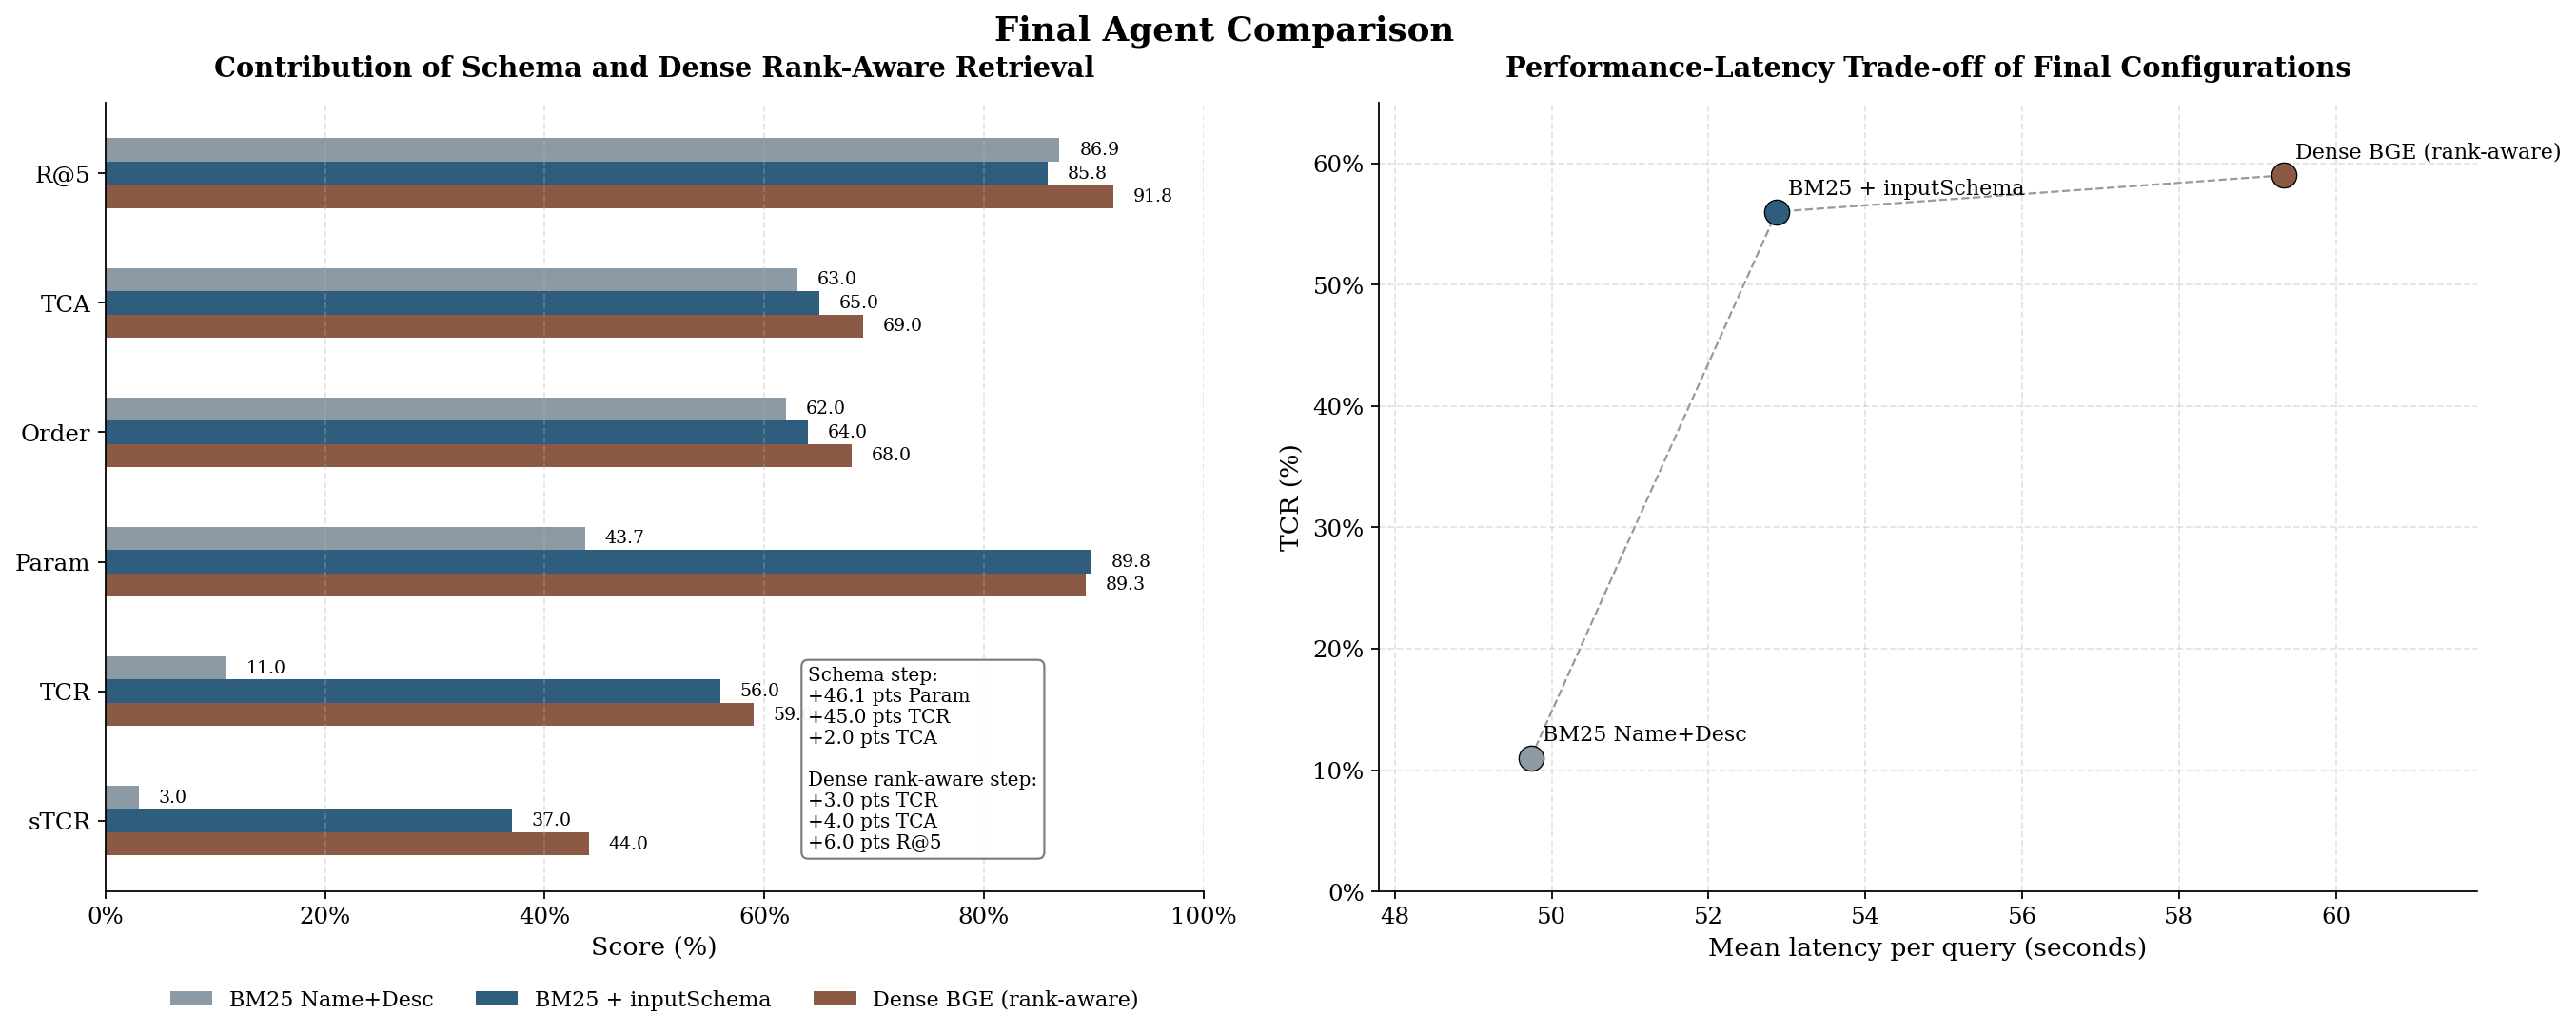

,Config,R@5,TCA,Order,Param,TCR,sTCR,Latency (s)
0,BM25 Name+Desc,86.9,63.0,62.0,43.7,11.0,3.0,49.7
1,BM25 + inputSchema,85.8,65.0,64.0,89.8,56.0,37.0,52.9
2,Dense BGE (rank-aware),91.8,69.0,68.0,89.3,59.0,44.0,59.3


In [ ]:
# Final dissertation-ready visualisations
# Uses final summary-table numbers only; no experiment rerun required.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
    "figure.dpi": 160,
    "savefig.dpi": 300,
})

# Final metrics from your notebook / dissertation table
df = pd.DataFrame([
    {
        "Config": "BM25 Name+Desc",
        "TCR": 11.0,
        "sTCR": 3.0,
        "TCA": 63.0,
        "ToolF1": 86.0,
        "Order": 62.0,
        "Param": 43.7,
        "R@5": 86.9,
        "Chain": 99.0,
        "Latency_ms": 49734
    },
    {
        "Config": "BM25 + inputSchema",
        "TCR": 56.0,
        "sTCR": 37.0,
        "TCA": 65.0,
        "ToolF1": 87.0,
        "Order": 64.0,
        "Param": 89.8,
        "R@5": 85.8,
        "Chain": 95.0,
        "Latency_ms": 52870
    },
    {
        "Config": "Dense BGE (rank-aware)",
        "TCR": 59.0,
        "sTCR": 44.0,
        "TCA": 69.0,
        "ToolF1": 90.2,
        "Order": 68.0,
        "Param": 89.3,
        "R@5": 91.8,
        "Chain": 100.0,
        "Latency_ms": 59337
    }
])

df["Latency_s"] = df["Latency_ms"] / 1000.0

colors = {
    "BM25 Name+Desc": "#8C9AA5",
    "BM25 + inputSchema": "#2F5D7E",
    "Dense BGE (rank-aware)": "#8A5A44",
}

# Slightly larger figure and manual spacing for cleaner layout
fig, axes = plt.subplots(
    1, 2,
    figsize=(17.5, 7.2),
    gridspec_kw={"wspace": 0.16},
    constrained_layout=False
)

plt.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.08,
    right=0.97
)


# Panel A: contribution of schema and dense rank-aware retrieval

ax = axes[0]

metrics = ["R@5", "TCA", "Order", "Param", "TCR", "sTCR"]
y = np.arange(len(metrics))
h = 0.18

bars_all = []
offsets = [-h, 0, h]

for offset, (_, row) in zip(offsets, df.iterrows()):
    vals = row[metrics].values.astype(float)
    bars = ax.barh(
        y + offset,
        vals,
        height=h,
        color=colors[row["Config"]],
        label=row["Config"]
    )
    bars_all.append(bars)

ax.set_title("Contribution of Schema and Dense Rank-Aware Retrieval", pad=12)
ax.set_yticks(y)
ax.set_yticklabels(metrics)
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.invert_yaxis()

# Value labels with a bit more room
for bars in bars_all:
    for b in bars:
        wv = b.get_width()
        ax.text(
            wv + 1.8,
            b.get_y() + b.get_height() / 2,
            f"{wv:.1f}",
            ha="left",
            va="center",
            fontsize=8.5
        )

baseline = df.iloc[0]
schema = df.iloc[1]
dense = df.iloc[2]

delta_param_schema = schema["Param"] - baseline["Param"]
delta_tcr_schema = schema["TCR"] - baseline["TCR"]
delta_tca_schema = schema["TCA"] - baseline["TCA"]
delta_tcr_dense = dense["TCR"] - schema["TCR"]
delta_tca_dense = dense["TCA"] - schema["TCA"]
delta_r5_dense = dense["R@5"] - schema["R@5"]

# Repositioned annotation box so it does not fight with legend/bars
ax.text(
    0.64,
    0.05,
    f"Schema step:\n"
    f"+{delta_param_schema:.1f} pts Param\n"
    f"+{delta_tcr_schema:.1f} pts TCR\n"
    f"+{delta_tca_schema:.1f} pts TCA\n\n"
    f"Dense rank-aware step:\n"
    f"+{delta_tcr_dense:.1f} pts TCR\n"
    f"+{delta_tca_dense:.1f} pts TCA\n"
    f"+{delta_r5_dense:.1f} pts R@5",
    fontsize=9.0,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#777777",
        alpha=0.95
    )
)

# Legend moved outside lower area for neatness
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    fontsize=10
)


# Panel B: latency-performance trade-off

ax = axes[1]

for _, row in df.iterrows():
    ax.scatter(
        row["Latency_s"],
        row["TCR"],
        s=140,
        color=colors[row["Config"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

# Dashed trend line
ax.plot(
    df["Latency_s"],
    df["TCR"],
    color="#999999",
    linestyle="--",
    linewidth=1,
    zorder=1
)

# Manual label placement for cleaner spacing
label_offsets = {
    "BM25 Name+Desc": (0.15, 1.0),
    "BM25 + inputSchema": (0.15, 1.0),
    "Dense BGE (rank-aware)": (0.15, 1.0),
}

for _, row in df.iterrows():
    dx, dy = label_offsets[row["Config"]]
    ax.text(
        row["Latency_s"] + dx,
        row["TCR"] + dy,
        row["Config"],
        fontsize=10,
        va="bottom"
    )

ax.set_title("Performance-Latency Trade-off of Final Configurations", pad=12)
ax.set_xlabel("Mean latency per query (seconds)")
ax.set_ylabel("TCR (%)")
ax.set_xlim(47.8, 61.8)
ax.set_ylim(0, 65)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(True, linestyle="--", alpha=0.35)

fig.suptitle(
    "Final Agent Comparison",
    fontsize=16,
    fontweight="bold",
    y=0.94
)

plt.show()

fig.savefig("final_agent_comparison_formal.png", bbox_inches="tight")
fig.savefig("final_agent_comparison_formal.pdf", bbox_inches="tight")

display(
    df[["Config", "R@5", "TCA", "Order", "Param", "TCR", "sTCR", "Latency_s"]]
    .rename(columns={"Latency_s": "Latency (s)"})
    .round(1)
)


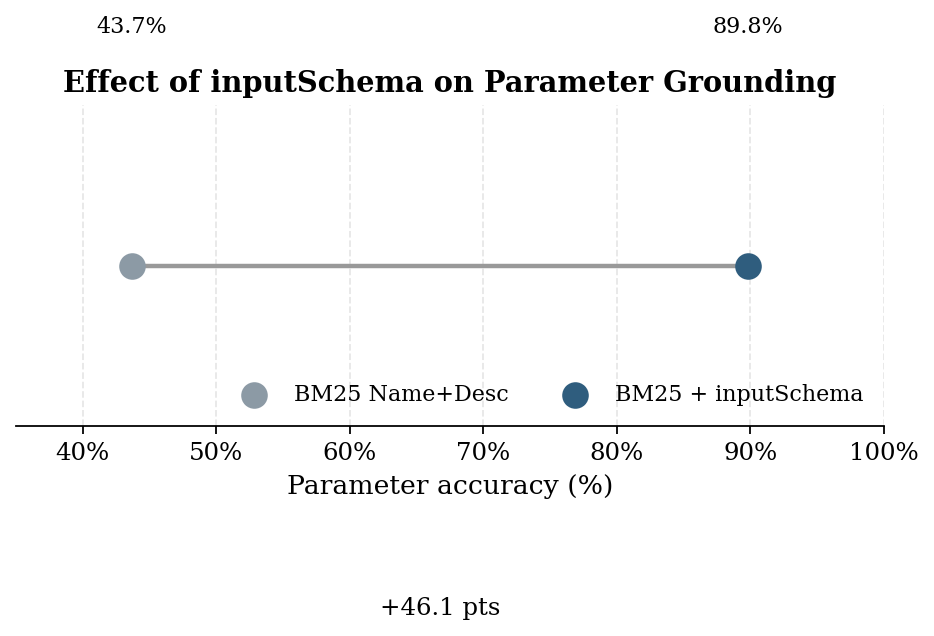

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

baseline = 43.7
schema = 89.8

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.hlines(1, baseline, schema, color="#999999", linewidth=2)
ax.scatter(baseline, 1, s=120, color="#8C9AA5", label="BM25 Name+Desc", zorder=3)
ax.scatter(schema, 1, s=120, color="#2F5D7E", label="BM25 + inputSchema", zorder=3)

ax.text(baseline, 1.08, f"{baseline:.1f}%", ha="center", fontsize=10)
ax.text(schema, 1.08, f"{schema:.1f}%", ha="center", fontsize=10)
ax.text((baseline + schema) / 2, 0.88, f"+{schema - baseline:.1f} pts", ha="center", fontsize=11)

ax.set_xlim(35, 100)
ax.set_yticks([])
ax.set_xlabel("Parameter accuracy (%)")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_title("Effect of inputSchema on Parameter Grounding")
ax.legend(loc="lower right", ncol=2, frameon=False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()
fig.savefig("schema_param_gain_dumbbell.png", bbox_inches="tight", dpi=300)
fig.savefig("schema_param_gain_dumbbell.pdf", bbox_inches="tight")
